In [ ]:
# Si no tiene scikit-image instalada ejecutar la celda siguiente
# pip install scikit-image

In [77]:
# Importaciones
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import os
import math
import glob
import shutil
import random
import time
import copy
from pathlib import Path

import torch
import torch.nn as nn
from torchinfo import summary
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score


In [43]:
# ============================================================
# CONFIGURACIÓN DE PYTORCH, GPU Y RUTAS DEL PROYECTO
# ============================================================

SEED_GLOBAL = 42

def fijar_semillas(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

fijar_semillas(SEED_GLOBAL)

print("PyTorch version:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU detectada:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("PyTorch NO detectó GPU. El notebook correrá en CPU.")
    device = torch.device("cpu")

print("Dispositivo usado:", device)

# ============================================================
# RUTAS
# ============================================================
# En Colab, si usas Drive, deja RUTA_PROYECTO como /content/drive/MyDrive.
# Si tus carpetas están en una subcarpeta, cambia por ejemplo a:
# RUTA_PROYECTO = "/content/drive/MyDrive/Cripto"
#
# En local, cambia RUTA_PROYECTO por la carpeta donde tengas dataset y bossbase_completo.
# Ejemplo Windows:
# RUTA_PROYECTO = r"C:\Users\TU_USUARIO\Documents\proyecto_cripto"

try:
    from google.colab import drive
    drive.mount('/content/drive')
    RUTA_PROYECTO = "/content/drive/MyDrive"
except Exception:
    RUTA_PROYECTO = "."

# Si no están directamente en MyDrive o en la carpeta del notebook, modifica esta variable.
# RUTA_PROYECTO = r"C:\ruta\a\tu\proyecto"

# Rutas principales
directorio_base = os.path.join(RUTA_PROYECTO, "dataset")
directorio_cover = os.path.join(directorio_base, "cover")
directorio_stego_7 = os.path.join(directorio_base, "stego_7")
directorio_stego_15 = os.path.join(directorio_base, "stego_15")
directorio_bossbase = os.path.join(RUTA_PROYECTO, "bossbase_completo", "BOSSbase_1.01")

EXTENSIONES_IMG = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.pgm", "*.tif", "*.tiff"]

def contar_imagenes(carpeta):
    total = 0
    for ext in EXTENSIONES_IMG:
        total += len(glob.glob(os.path.join(carpeta, ext)))
    return total

carpetas_requeridas = [
    directorio_base,
    directorio_cover,
    directorio_stego_7,
    directorio_stego_15
]

for carpeta in carpetas_requeridas:
    if not os.path.isdir(carpeta):
        raise FileNotFoundError(
            f"No se encontró la carpeta: {carpeta}\n"
            "Revisa RUTA_PROYECTO o la estructura de carpetas."
        )

print("\nDataset configurado:")
print(f"directorio_base: {directorio_base}")
print(f"cover:           {contar_imagenes(directorio_cover)} imágenes")
print(f"stego_7:         {contar_imagenes(directorio_stego_7)} imágenes")
print(f"stego_15:        {contar_imagenes(directorio_stego_15)} imágenes")


PyTorch version: 2.7.1+cu118
CUDA disponible: True
GPU detectada: NVIDIA GeForce RTX 4090
Dispositivo usado: cuda

Dataset configurado:
directorio_base: .\dataset
cover:           1000 imágenes
stego_7:         1000 imágenes
stego_15:        1000 imágenes


# **Fase 1: Implementaciones de Matriz Embedding y Extracciones de Mensajes**

## **1.1. Código Hamming (7,4)**

### **1.1.1. Implementación de Matrix Embedding con Código Hamming (7,4)**

El objetivo del Matrix Embedding es minimizar la cantidad de modificaciones necesarias en la imagen de cobertura, reduciendo así la distorsión estadística. Utilizando un código Hamming (7,4), podemos ocultar 3 bits de información secreta en un bloque de 7 píxeles alterando, como máximo, un solo bit menos significativo (LSB).

Matemáticamente, definimos la matriz de comprobación de paridad $H$ de dimensiones $3 \times 7$. Para un bloque de píxeles $x$, calculamos su síndrome actual. Si la diferencia entre el mensaje secreto y el síndrome actual no es nula, el vector resultante nos indica exactamente el índice de la columna en $H$ (y por ende, el píxel) que debe ser modificado para que el nuevo síndrome coincida con el secreto.

In [44]:
def embed_hamming_7_3(pixels_block, secret_bits):
    """
    Oculta 3 bits secretos en un bloque de 7 píxeles.
    pixels_block: array de numpy con 7 valores (ej. [150, 151, 149...])
    secret_bits: array de numpy con 3 bits (ej. [1, 0, 1])
    """
    # 1. Matriz de paridad H para Hamming (7,4)
    H = np.array([
        [0, 0, 0, 1, 1, 1, 1],
        [0, 1, 1, 0, 0, 1, 1],
        [1, 0, 1, 0, 1, 0, 1]
    ])

    # 2. Extraer los LSB (Bits Menos Significativos) del bloque de píxeles
    x = pixels_block % 2

    # 3. Calcular el síndrome actual: s_current = H * x^T (mod 2)
    s_current = np.dot(H, x) % 2

    # 4. Calcular la diferencia con el secreto que queremos: d = secret - s_current (mod 2)
    d = (secret_bits - s_current) % 2

    # 5. Encontrar qué píxel debemos cambiar
    # Convertimos el vector 'd' a un número entero (que coincide con la columna en H)
    index_to_change = d[0]*4 + d[1]*2 + d[2]*1

    modified_pixels = pixels_block.copy()

    # Si el índice es 0, la imagen ya tiene el mensaje por pura casualidad (¡No hacemos nada!)
    # Si es > 0, alteramos el LSB del píxel en la posición correspondiente
    if index_to_change > 0:
        idx = index_to_change - 1

        # Invertir el LSB: si es par suma 1, si es impar resta 1
        if modified_pixels[idx] % 2 == 0:
            modified_pixels[idx] += 1
        else:
            modified_pixels[idx] -= 1

    return modified_pixels

## **1.1.2. Extracción del Mensaje con Código Hamming (7,4)**

La principal ventaja de este esquema es la eficiencia en la recuperación. Para extraer el mensaje de la imagen stego, el receptor no necesita conocer la imagen original. Basta con extraer los LSB de los bloques de 7 píxeles y multiplicarlos por la misma matriz de comprobación de paridad $H$. El síndrome resultante será exactamente el mensaje secreto incrustado.

In [45]:
def extract_hamming_7_3(stego_pixels_block):
    """
    Extrae los 3 bits secretos ocultos en un bloque de 7 píxeles stego.
    stego_pixels_block: array de numpy con 7 valores modificados.
    """
    H = np.array([
        [0, 0, 0, 1, 1, 1, 1],
        [0, 1, 1, 0, 0, 1, 1],
        [1, 0, 1, 0, 1, 0, 1]
    ])

    # 1. Extraer los LSB del bloque stego
    x_stego = stego_pixels_block % 2

    # 2. El mensaje secreto es simplemente el síndrome del bloque
    extracted_bits = np.dot(H, x_stego) % 2

    return extracted_bits

### **1.1.3. Validación Funcional: Inserción y Extracción con Hamming (7,4)**

Para comprobar la correctitud matemática de las operaciones algebraicas de los síndromes, se diseñó una prueba unitaria aislada. Se inyectó el vector secreto [1, 0, 1] en un bloque de control de 7 píxeles.

In [46]:
# --- Bloque de Prueba Unitaria ---
print("--- Prueba de Funcionamiento ---")
original_pixels = np.array([150, 151, 149, 152, 153, 154, 155])
secret = np.array([1, 0, 1])

print(f"Píxeles originales: {original_pixels}")
print(f"Secreto a ocultar:  {secret}")

# Proceso de embedding
stego_pixels = embed_hamming_7_3(original_pixels, secret)
print(f"Píxeles stego:      {stego_pixels}")

# Proceso de extracción
recovered_secret = extract_hamming_7_3(stego_pixels)
print(f"Secreto recuperado: {recovered_secret}")
print(f"¿Éxito?: {'Sí' if np.array_equal(secret, recovered_secret) else 'No'}")

--- Prueba de Funcionamiento ---
Píxeles originales: [150 151 149 152 153 154 155]
Secreto a ocultar:  [1 0 1]
Píxeles stego:      [150 151 149 152 153 155 155]
Secreto recuperado: [1 0 1]
¿Éxito?: Sí


Como se evidencia en los resultados de ejecución, el algoritmo modificó de manera exitosa un único píxel (pasando el penúltimo valor de 154 a 155) para satisfacer la matriz de paridad. Posteriormente, la función de extracción ciega recuperó el secreto original en su totalidad, validando la integridad del diseño algorítmico y demostrando la eficiencia del Matrix Embedding de primer orden.

## **1.2. Código (15,11)**

### **1.2.1. Escalamiento a Matrix Embedding con Hamming (15,11)**

Para analizar un escenario de mayor eficiencia de inserción, implementamos el código Hamming (15,11). En esta configuración, la matriz de comprobación de paridad $H$ tiene dimensiones de $4 \times 15$. Esto nos permite ocultar 4 bits de información en un bloque de 15 píxeles, realizando como máximo una sola modificación.

Teóricamente, esto ofrece un mejor compromiso (trade-off) entre la carga útil y la distorsión estadística, ya que la probabilidad de alterar un píxel disminuye proporcionalmente en bloques más grandes, lo cual evaluaremos frente a las redes residuales.

In [47]:
def embed_hamming_15_11(pixels_block, secret_bits):
    """
    Oculta 4 bits secretos en un bloque de 15 píxeles usando Matrix Embedding.
    pixels_block: array de numpy con 15 valores (ej. [150, 151, ... 164])
    secret_bits: array de numpy con 4 bits (ej. [1, 0, 1, 1])
    """
    # 1. Matriz H de 4x15. Las columnas representan los números del 1 al 15 en binario.
    H = np.array([
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1], # Fila de los 8s
        [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1], # Fila de los 4s
        [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1], # Fila de los 2s
        [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]  # Fila de los 1s
    ])

    x = pixels_block % 2
    s_current = np.dot(H, x) % 2
    d = (secret_bits - s_current) % 2

    # 2. Encontrar el índice a modificar (conversión de 4 bits a decimal)
    index_to_change = d[0]*8 + d[1]*4 + d[2]*2 + d[3]*1

    modified_pixels = pixels_block.copy()

    # 3. Modificar el píxel correspondiente si es necesario
    if index_to_change > 0:
        idx = index_to_change - 1

        if modified_pixels[idx] % 2 == 0:
            modified_pixels[idx] += 1
        else:
            modified_pixels[idx] -= 1

    return modified_pixels

### **1.2.2. Extracción del Mensaje con Hamming (15,11)**

De manera análoga al esquema de menor orden, la recuperación de los datos incrustados mediante Hamming (15,11) se realiza de forma ciega, lo que significa que el receptor no requiere acceso a la imagen de cobertura original para extraer el payload.

El proceso de extracción consiste en segmentar la imagen stego en bloques independientes de 15 píxeles, aislar sus bits menos significativos (LSB) y calcular el producto punto de este vector contra la matriz de comprobación de paridad $H$ de dimensiones $4 \times 15$. El vector resultante de 4 bits corresponde al síndrome del bloque, el cual, por la propiedad del Matrix Embedding, es matemáticamente equivalente al fragmento del mensaje secreto original.

In [48]:
def extract_hamming_15_11(stego_pixels_block):
    """
    Extrae los 4 bits secretos ocultos en un bloque de 15 píxeles stego.
    """
    H = np.array([
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1],
        [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1],
        [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
    ])

    x_stego = stego_pixels_block % 2
    extracted_bits = np.dot(H, x_stego) % 2

    return extracted_bits

### **Validación Funcional: Inserción y Extracción con Hamming (15,11)**

De forma equivalente, se evaluó el comportamiento del esquema de mayor orden. Al incrustar un payload de 4 bits ([1, 1, 0, 1]) en un bloque continuo de 15 píxeles, el motor de inserción determinó matemáticamente que solo era necesario alterar un píxel (modificando el valor 132 por 133) para que el nuevo síndrome del bloque coincidiera exactamente con el secreto.


In [49]:
# --- Bloque de Prueba Unitaria ---
print("--- Prueba Hamming (15,11) ---")
original_pixels_15 = np.array([120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134])
secret_4bits = np.array([1, 1, 0, 1])

stego_pixels_15 = embed_hamming_15_11(original_pixels_15, secret_4bits)
recovered_secret_15 = extract_hamming_15_11(stego_pixels_15)

print(f"Píxeles originales: {original_pixels_15}")
print(f"Secreto a ocultar:  {secret_4bits}")
print(f"Píxeles stego:      {stego_pixels_15}")
print(f"Secreto recuperado: {recovered_secret_15}")
print(f"¿Éxito?: {'Sí' if np.array_equal(secret_4bits, recovered_secret_15) else 'No'}")

--- Prueba Hamming (15,11) ---
Píxeles originales: [120 121 122 123 124 125 126 127 128 129 130 131 132 133 134]
Secreto a ocultar:  [1 1 0 1]
Píxeles stego:      [120 121 122 123 124 125 126 127 128 129 130 131 133 133 134]
Secreto recuperado: [1 1 0 1]
¿Éxito?: Sí


La recuperación demostró ser 100% precisa, confirmando que la lógica de prevención de desbordamientos de rango para los LSB funciona sin corromper la información subyacente.

## **1.3. Conclusión de la Fase 1: Implementación de Algoritmos**

La primera fase experimental del proyecto confirma que la implementación de los códigos Hamming (7,4) y (15,11) en el dominio espacial es computacionalmente precisa. Ambos algoritmos logran ocultar flujos de bits minimizando la tasa de alteración a un máximo estricto de una modificación por bloque, lo cual garantiza la alta eficiencia de incrustación que fundamenta la técnica de Matrix Embedding.

Al validar que la matemática de los síndromes opera correctamente y que los algoritmos manejan la inversión de los bits menos significativos (LSB) sin inducir errores de rango en la escala de grises, se establece una base algorítmica robusta. Esto permite dar por concluida la implementación criptográfica y avanzar con garantías hacia el procesamiento de imágenes a gran escala, la generación del corpus experimental y la posterior confrontación contra el esteganálisis basado en redes residuales.

# **Fase 2: Procesamiento de Imágenes y Generación de Dataset**

## **2.1. Motor de Inserción y Procesamiento de Imágenes**

Para escalar la técnica de Matrix Embedding a imágenes completas, se desarrolló un motor de procesamiento que opera en el dominio espacial. El flujo de trabajo consiste en:

1. Conversión a Escala de Grises: Se trabaja sobre un solo canal para simplificar la demostración de la eficiencia de los códigos Hamming.

2. Serialización del Payload: El mensaje secreto se convierte en un flujo de bits aleatorios.

3. Segmentación por Bloques: La imagen se aplanada y se divide en bloques de tamaño $n$ (7 o 15), aplicando la modificación de LSB correspondiente según el síndrome calculado.

4. Preservación de Integridad: Los resultados se almacenan en formato PNG (Lossless) para evitar que la compresión por transformada de coseno (como en JPEG) destruya la información oculta en los bits menos significativos.

In [50]:
def process_full_image(image_path, n_type=7):
    """
    Carga una imagen, oculta un mensaje aleatorio y la guarda.
    n_type: 7 para Hamming(7,4) o 15 para Hamming(15,11)
    """
    # 1. Cargar imagen en escala de grises
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: No se pudo cargar {image_path}")
        return

    h, w = img.shape
    pixels = img.flatten() # Aplanar para iterar fácilmente

    # Definir parámetros según el tipo de Hamming seleccionado
    if n_type == 7:
        n, k_bits = 7, 3
        embed_func = embed_hamming_7_3
    else:
        n, k_bits = 15, 4
        embed_func = embed_hamming_15_11

    # 2. Calcular capacidad y generar secreto aleatorio
    num_blocks = len(pixels) // n
    total_secret_bits = num_blocks * k_bits
    # Generamos un secreto aleatorio para la prueba (simulando datos cifrados)
    secret_payload = np.random.randint(0, 2, total_secret_bits)

    # 3. Iterar por bloques y aplicar embedding
    stego_pixels = pixels.copy()
    for i in range(num_blocks):
        start_px = i * n
        start_bit = i * k_bits

        block = pixels[start_px : start_px + n]
        bits = secret_payload[start_bit : start_bit + k_bits]

        stego_pixels[start_px : start_px + n] = embed_func(block, bits)

    # 4. Reconstruir la imagen 2D
    stego_img = stego_pixels.reshape((h, w))

    # 5. Guardar resultado en formato PNG (Crucial: NO usar JPG)
    output_name = f"stego_{n_type}_{os.path.basename(image_path)}"
    cv2.imwrite(output_name, stego_img)

    print(f"Imagen generada con éxito: {output_name}")
    print(f"Bits ocultos: {total_secret_bits} | Eficiencia: 1 cambio máx por bloque de {n} px.")
    return output_name

## **2.2. Ejecución y Análisis de Capacidad (Prueba Piloto)**

Para validar el funcionamiento del motor de inserción y observar el comportamiento de las tasas de incrustación espacial sin depender de recursos externos, se genera dinámicamente una imagen de control sintética de $256 \times 256$ píxeles.

Sobre esta matriz controlada se aplican ambos esquemas de Matrix Embedding, haciendo evidente el compromiso inherente entre la longitud del bloque y la capacidad de carga útil (payload):

* Esquema Hamming (7,4): Tasa teórica de $\approx 0.43$ bits por píxel.

* Esquema Hamming (15,11): Tasa teórica de $\approx 0.27$ bits por píxel.

Esta prueba aísla la lógica matemática de los síndromes antes de escalar el procesamiento al corpus completo.

In [51]:
print("--- 1. Generación de Imagen de Control ---")
# Creamos una imagen sintética de 256x256 con ruido aleatorio (simulando texturas)
imagen_sintetica = np.random.randint(0, 256, (256, 256), dtype=np.uint8)
ruta_prueba = 'imagen_de_prueba_sintetica.png'
cv2.imwrite(ruta_prueba, imagen_sintetica)
print(f"Imagen temporal creada: {ruta_prueba} (Dimensiones: 256x256)")

print("\n--- 2. Prueba de Inserción con Hamming (7,4) ---")
img_7_path = process_full_image(ruta_prueba, n_type=7)

print("\n--- 3. Prueba de Inserción con Hamming (15,11) ---")
img_15_path = process_full_image(ruta_prueba, n_type=15)

--- 1. Generación de Imagen de Control ---
Imagen temporal creada: imagen_de_prueba_sintetica.png (Dimensiones: 256x256)

--- 2. Prueba de Inserción con Hamming (7,4) ---
Imagen generada con éxito: stego_7_imagen_de_prueba_sintetica.png
Bits ocultos: 28086 | Eficiencia: 1 cambio máx por bloque de 7 px.

--- 3. Prueba de Inserción con Hamming (15,11) ---
Imagen generada con éxito: stego_15_imagen_de_prueba_sintetica.png
Bits ocultos: 17476 | Eficiencia: 1 cambio máx por bloque de 15 px.


El código (7,4) permite ocultar un volumen significativamente mayor de información que el código (15,11) para las mismas dimensiones espaciales. Sin embargo, esta mayor capacidad está intrínsecamente ligada a una mayor densidad de modificaciones, lo que se evaluará estadísticamente en la siguiente fase.

In [52]:
# Limpieza de Artefactos de Prueba
archivos_a_eliminar = [ruta_prueba, img_7_path, img_15_path]

print("--- Intentando eliminar artefactos de prueba ---")
for archivo in archivos_a_eliminar:
    if os.path.exists(archivo):
        os.remove(archivo)
        print(f"Artefacto temporal eliminado: {archivo}")
    else:
        print(f"Artefacto {archivo} no encontrado (ya eliminado o nunca creado).")


# Verificar que los archivos hayan sido eliminados
print("\n--- Verificación de eliminación ---")
for archivo in archivos_a_eliminar:
    if not os.path.exists(archivo):
        print(f"Verificado: {archivo} ha sido eliminado exitosamente.")
    else:
        print(f"Error: {archivo} aún existe.")

--- Intentando eliminar artefactos de prueba ---
Artefacto temporal eliminado: imagen_de_prueba_sintetica.png
Artefacto temporal eliminado: stego_7_imagen_de_prueba_sintetica.png
Artefacto temporal eliminado: stego_15_imagen_de_prueba_sintetica.png

--- Verificación de eliminación ---
Verificado: imagen_de_prueba_sintetica.png ha sido eliminado exitosamente.
Verificado: stego_7_imagen_de_prueba_sintetica.png ha sido eliminado exitosamente.
Verificado: stego_15_imagen_de_prueba_sintetica.png ha sido eliminado exitosamente.


## **2.3. Adquisición y Preparación del Dataset BOSSBase**

Para garantizar la validez científica del esteganálisis, se optó por utilizar BOSSBase 1.01 (Break Our Steganographic System), un corpus estandarizado en la literatura de seguridad de la información. Este conjunto de datos consta de imágenes en formato PGM (Portable Gray Map) con texturas ricas y ruido de sensor natural, lo que las hace ideales como imágenes de cobertura.

La adquisición original del material se realizó descargando el archivo oficial de BOSSBase 1.01 desde el repositorio del DDE Lab de Binghamton University:

```text
http://dde.binghamton.edu/download/ImageDB/BOSSbase_1.01.zip
```

Después de la descarga, el archivo comprimido se extrajo en una carpeta temporal llamada `bossbase_completo/`. A partir de allí, se localizaron las imágenes `.pgm` incluidas en el directorio `BOSSbase_1.01/`.

Como el conjunto completo contiene 10.000 imágenes, se definió una cantidad inicial de imágenes a procesar mediante la variable `CANTIDAD_A_PROCESAR`. En este caso, se seleccionaron las primeras 1.000 imágenes del corpus para construir el conjunto experimental de cobertura. Estas imágenes fueron copiadas a la carpeta de trabajo:

```bash
dataset/cover/
```

Este paso no modificó el contenido visual de las imágenes ni aplicó transformaciones como recorte, redimensionamiento, normalización, rotación o compresión. El único preprocesamiento realizado fue la organización de los archivos dentro de la estructura local del proyecto. Por tanto, las imágenes de cobertura conservan su formato original `.pgm` y su información de intensidad en escala de grises.

A partir de esta carpeta `dataset/cover/`, posteriormente se generaron las imágenes esteganográficas correspondientes a los esquemas Hamming (7,4) y Hamming (15,11). Como resultado, la carpeta `dataset/` quedó organizada de la siguiente manera:

```text
dataset/
├── cover/
├── stego_7/
└── stego_15/
```

La carpeta `cover/` contiene las imágenes originales de cobertura tomadas de BOSSBase. La carpeta `stego_7/` contiene las imágenes modificadas mediante Matrix Embedding con Hamming (7,4), mientras que `stego_15/` contiene las imágenes modificadas mediante Matrix Embedding con Hamming (15,11).

En esta implementación, esta carpeta `dataset/` ya se encuentra construida previamente y se lee directamente desde el almacenamiento local o desde Google Drive, dependiendo del entorno de ejecución. Por esta razón, no se descarga ni extrae BOSSBase en cada ejecución, sino que reutiliza la estructura de datos previamente generada.


In [ ]:
# ============================================================
# USO DEL DATASET YA CONSTRUIDO
# ============================================================
# La descarga original de BOSSBase 1.01, la extracción del ZIP
# y la copia de imágenes a dataset/cover se realizaron previamente.
#
# Se reutiliza la carpeta dataset/ ya creada, la cual contiene:
#   directorio_base/cover
#   directorio_base/stego_7
#   directorio_base/stego_15
# ============================================================

print("Se omite la descarga y clasificación porque el dataset ya existe.")
print(f"Dataset base: {directorio_base}")
print(f"Cover:        {contar_imagenes(directorio_cover)} imágenes")
print(f"Stego 7:      {contar_imagenes(directorio_stego_7)} imágenes")
print(f"Stego 15:     {contar_imagenes(directorio_stego_15)} imágenes")


Se omite la descarga y clasificación porque el dataset ya existe.
Dataset base: .\dataset
Cover:        1000 imágenes
Stego 7:      1000 imágenes
Stego 15:     1000 imágenes


## **2.4. Generación del Corpus Esteganográfico (Procesamiento por Lotes)**

Una vez consolidado el directorio base con las imágenes oficiales del corpus BOSSBase, se procedió a la generación masiva de los conjuntos de datos modificados.

El proyecto contiene la función `generate_stego_dataset()`, una función iterativa que recorre la totalidad de las imágenes de cobertura, extrae sus matrices de píxeles y aplica, de manera independiente, las rutinas de Matrix Embedding para los códigos Hamming (7,4) y (15,11). Las imágenes resultantes se exportan forzosamente en formato PNG (Portable Network Graphics) dentro de sus respectivos directorios (stego_7 y stego_15). Esta conversión de formato es una medida crítica para asegurar una compresión sin pérdidas (lossless), previniendo así la destrucción de los bits menos significativos (LSB) que contienen el payload incrustado. Esta función recorre el directorio de imágenes originales, aplica de manera independiente los esquemas Hamming (7,4) y Hamming (15,11), y guarda los resultados en los directorios `stego_7` y `stego_15`.

Sin embargo, en la configuración actual no se regenera el corpus automáticamente. La variable `REGENERAR_STEGO` se mantiene en `False`, por lo que el notebook reutiliza las imágenes stego ya existentes en disco. Esto evita sobrescribir archivos, reduce el tiempo de ejecución y permite trabajar directamente con un dataset previamente construido.

En caso de necesitar reconstruir el corpus desde cero, basta con cambiar manualmente:

```python
REGENERAR_STEGO = True
```

Solo debe hacerse si las carpetas cover, stego_7 y stego_15 deben volver a sincronizarse o si se modificó la lógica de inserción del payload.

In [54]:
# --- 1. Definición de la Función Principal ---
def generate_stego_dataset(input_dir, output_dir_7, output_dir_15, max_images=None):
    """
    Recorre una carpeta de imágenes originales y genera dos datasets stego completos.
    """
    os.makedirs(output_dir_7, exist_ok=True)
    os.makedirs(output_dir_15, exist_ok=True)

    image_paths = glob.glob(os.path.join(input_dir, '*.*'))

    if max_images:
        image_paths = image_paths[:max_images]

    print(f"Iniciando procesamiento de {len(image_paths)} imágenes. Esto puede tardar varios minutos...")

    for idx, img_path in enumerate(image_paths):
        filename = os.path.basename(img_path)
        name_without_ext = os.path.splitext(filename)[0]
        output_name = f"{name_without_ext}.png" # Forzamos PNG sin pérdidas

        path_out_7 = os.path.join(output_dir_7, output_name)
        path_out_15 = os.path.join(output_dir_15, output_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        h, w = img.shape
        pixels = img.flatten()

        # --- Procesamiento Hamming (7,4) ---
        num_blocks_7 = len(pixels) // 7
        secret_7 = np.random.randint(0, 2, num_blocks_7 * 3)
        stego_pixels_7 = pixels.copy()

        for i in range(num_blocks_7):
            start_px, start_bit = i * 7, i * 3
            block = pixels[start_px : start_px + 7]
            bits = secret_7[start_bit : start_bit + 3]
            stego_pixels_7[start_px : start_px + 7] = embed_hamming_7_3(block, bits)

        cv2.imwrite(path_out_7, stego_pixels_7.reshape((h, w)))

        # --- Procesamiento Hamming (15,11) ---
        num_blocks_15 = len(pixels) // 15
        secret_15 = np.random.randint(0, 2, num_blocks_15 * 4)
        stego_pixels_15 = pixels.copy()

        for i in range(num_blocks_15):
            start_px, start_bit = i * 15, i * 4
            block = pixels[start_px : start_px + 15]
            bits = secret_15[start_bit : start_bit + 4]
            stego_pixels_15[start_px : start_px + 15] = embed_hamming_15_11(block, bits)

        cv2.imwrite(path_out_15, stego_pixels_15.reshape((h, w)))

        # Imprimir progreso cada 100 imágenes para no saturar la consola
        if (idx + 1) % 100 == 0 or (idx + 1) == len(image_paths):
            print(f"Progreso: {idx + 1}/{len(image_paths)} imágenes procesadas y guardadas.")

    print("\n¡Generación del corpus stego finalizada con éxito!")

### **2.4.1. Procesamiento Exhaustivo del Corpus BOSSBase**

Antes de entrenar los modelos, se verifica las rutas principales del corpus: imágenes `cover`, imágenes `stego_7` e imágenes `stego_15`. Esta verificación permite confirmar que la estructura esperada del dataset está disponible antes de construir los `DataLoader` de PyTorch.

La generación masiva del corpus queda controlada por la variable `REGENERAR_STEGO`. En la ejecución actual, esta variable está configurada como `False`, por lo que no se vuelven a crear las imágenes esteganográficas si estas ya existen. Esta configuración es importante porque evita modificar accidentalmente el conjunto experimental usado para entrenar y evaluar la red neuronal.

Por tanto, esta sección no debe interpretarse como una generación obligatoria del dataset en cada ejecución, sino como una etapa de control que permite reutilizar un corpus previamente generado o regenerarlo manualmente cuando sea necesario.

In [55]:
# --- Rutas del corpus ya existente ---
directorio_originales = directorio_cover

print("Rutas configuradas:")
print(f"Originales / cover: {directorio_originales}")
print(f"Stego 7:            {directorio_stego_7}")
print(f"Stego 15:           {directorio_stego_15}")


Rutas configuradas:
Originales / cover: .\dataset\cover
Stego 7:            .\dataset\stego_7
Stego 15:           .\dataset\stego_15


In [56]:
# ============================================================
# NO REGENERAR DATASET STEGO SI YA EXISTE
# ============================================================

REGENERAR_STEGO = False

if REGENERAR_STEGO:
    generate_stego_dataset(
        input_dir=directorio_originales,
        output_dir_7=directorio_stego_7,
        output_dir_15=directorio_stego_15
    )
else:
    print("Se omite la generación de imágenes stego porque el dataset ya existe.")
    print(f"Cover:    {contar_imagenes(directorio_cover)} imágenes")
    print(f"Stego 7:  {contar_imagenes(directorio_stego_7)} imágenes")
    print(f"Stego 15: {contar_imagenes(directorio_stego_15)} imágenes")


Se omite la generación de imágenes stego porque el dataset ya existe.
Cover:    1000 imágenes
Stego 7:  1000 imágenes
Stego 15: 1000 imágenes


# **Fase 3: Entrenamiento del Modelo de esteganálisis**

## **3.1. Construcción del Pipeline de Datos y Partición**

Para la fase de esteganálisis se utiliza PyTorch mediante un `Dataset` personalizado y objetos `DataLoader`. Las imágenes se leen directamente desde las carpetas `cover`, `stego_7` y `stego_15`, evitando depender de una carga completa del dataset en memoria.

El `DatasetEstego` carga cada imagen en escala de grises, la convierte a tensor con formato `(canales, alto, ancho)` y asigna una etiqueta binaria: `0` para imágenes de cobertura y `1` para imágenes stego. En esta versión, las imágenes se mantienen en escala `0-255` antes de entrar a la red, ya que la primera capa de la arquitectura corresponde a un filtro de alto paso fijo diseñado para operar sobre los residuos espaciales de la imagen.

Para evitar *data leakage*, la partición no se realiza a nivel de archivo individual, sino a nivel de imagen base. Primero se identifican los nombres comunes entre `cover` y la clase stego correspondiente. Luego, esos identificadores se dividen en entrenamiento, validación y test. De esta forma, una imagen limpia y su versión esteganográfica siempre quedan en el mismo subconjunto, evitando que el modelo vea durante entrenamiento una variante de una imagen que luego aparece en validación o test.

La partición actual es:

- 60% para entrenamiento.
- 25% para validación.
- 15% para test.

El conjunto de validación se utiliza durante el entrenamiento para monitorear el desempeño y guardar el mejor checkpoint. El conjunto de test se mantiene completamente separado y solo se evalúa al final, en la sección de métricas de clasificación.

Además, se aplica aumento de datos únicamente en entrenamiento mediante volteos horizontales y verticales. No se usan transformaciones agresivas como rotaciones, zoom, recortes o cambios de color, porque podrían alterar artificialmente la estructura de los LSB o introducir patrones no representativos del problema original.

Como primer paso de la construcción del pipeline, primero se verifica que todas las imágenes se encuentren en el formato adecuado (`.png`). 


In [57]:
# ============================================================
# VERIFICACIÓN / CONVERSIÓN OPCIONAL DE COVER A PNG
# ============================================================

print("--- Verificando formato del corpus cover ---")

rutas_png = glob.glob(os.path.join(directorio_cover, "*.png"))
rutas_pgm = glob.glob(os.path.join(directorio_cover, "*.pgm"))

print(f"Imágenes PNG encontradas en cover: {len(rutas_png)}")
print(f"Imágenes PGM encontradas en cover: {len(rutas_pgm)}")

# Keras ya no se usa, pero para mantener compatibilidad con el resto del análisis
# conviene tener PNG disponibles. No se borran los PGM originales.
if len(rutas_png) == 0 and len(rutas_pgm) > 0:
    print("No se encontraron PNG en cover. Convirtiendo PGM a PNG...")

    for ruta in rutas_pgm:
        img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            nueva_ruta = os.path.splitext(ruta)[0] + ".png"
            cv2.imwrite(nueva_ruta, img)

    rutas_png = glob.glob(os.path.join(directorio_cover, "*.png"))
    print(f"Conversión finalizada. PNG disponibles en cover: {len(rutas_png)}")
else:
    print("No es necesario convertir. El corpus cover ya tiene imágenes PNG o PyTorch leerá PGM directamente.")


--- Verificando formato del corpus cover ---
Imágenes PNG encontradas en cover: 1000
Imágenes PGM encontradas en cover: 0
No es necesario convertir. El corpus cover ya tiene imágenes PNG o PyTorch leerá PGM directamente.


In [58]:
print("--- 1. Definición de Parámetros Dinámicos ---")

# Se usan las rutas definidas en la celda de configuración.
# NO reasignar directorio_base a "./dataset/".

lista_imagenes = []
for ext in EXTENSIONES_IMG:
    lista_imagenes.extend(glob.glob(os.path.join(directorio_cover, ext)))
lista_imagenes = sorted(lista_imagenes)

if lista_imagenes:
    imagen_muestra = cv2.imread(lista_imagenes[0], cv2.IMREAD_GRAYSCALE)
    ALTO_IMG, ANCHO_IMG = imagen_muestra.shape
else:
    ALTO_IMG, ANCHO_IMG = 512, 512

BATCH_SIZE = 32
SEMILLA = 42
VALIDATION_SPLIT = 0.25
TEST_SPLIT = 0.15
NUM_WORKERS = 0  # En Windows/Jupyter es más estable dejarlo en 0.
PIN_MEMORY = (device.type == "cuda")

print(f"Dataset usado: {directorio_base}")
print(f"Dimensiones de entrada configuradas a: {ALTO_IMG}x{ANCHO_IMG}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Split por imagen base: train={1 - VALIDATION_SPLIT - TEST_SPLIT:.0%}, val={VALIDATION_SPLIT:.0%}, test={TEST_SPLIT:.0%}")
print(f"Pin memory: {PIN_MEMORY}")


--- 1. Definición de Parámetros Dinámicos ---
Dataset usado: .\dataset
Dimensiones de entrada configuradas a: 512x512
Batch size: 32
Split por imagen base: train=60%, val=25%, test=15%
Pin memory: True


In [59]:
print("\n--- 2. Partición por imagen base con PyTorch: Train / Val / Test ---")

class DatasetEstego(Dataset):
    def __init__(self, rutas, etiquetas, alto, ancho, augment=False):
        self.rutas = list(rutas)
        self.etiquetas = list(etiquetas)
        self.alto = alto
        self.ancho = ancho
        self.augment = augment

    def __len__(self):
        return len(self.rutas)

    def __getitem__(self, idx):
        ruta = self.rutas[idx]
        etiqueta = self.etiquetas[idx]

        img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"No se pudo leer la imagen: {ruta}")

        # Mantener interpolación nearest para no alterar innecesariamente los LSB.
        if img.shape != (self.alto, self.ancho):
            img = cv2.resize(img, (self.ancho, self.alto), interpolation=cv2.INTER_NEAREST)

        # PyTorch usa formato NCHW. Valores en escala 0-255, igual que el flujo original.
        img = img.astype(np.float32)
        img = torch.from_numpy(img).unsqueeze(0)  # (1, H, W)

        # Data augmentation conservadora: solo flips. No se usan rotaciones, zoom ni color jitter.
        if self.augment:
            if random.random() < 0.5:
                img = torch.flip(img, dims=[2])  # flip horizontal
            if random.random() < 0.5:
                img = torch.flip(img, dims=[1])  # flip vertical

        etiqueta = torch.tensor([float(etiqueta)], dtype=torch.float32)
        return img, etiqueta


def listar_imagenes_clase(directorio_clase):
    rutas = []
    for ext in EXTENSIONES_IMG:
        rutas.extend(glob.glob(os.path.join(directorio_clase, ext)))
    return sorted(rutas)


def listar_imagenes_por_stem(directorio_clase):
    """
    Retorna un diccionario {stem: ruta_imagen}. Si existen duplicados con el mismo
    nombre base y extensiones distintas, prioriza PNG para mantener consistencia.
    """
    prioridad_extension = {
        ".png": 0,
        ".pgm": 1,
        ".bmp": 2,
        ".tif": 3,
        ".tiff": 4,
        ".jpg": 5,
        ".jpeg": 6,
    }

    por_stem = {}
    for ruta in listar_imagenes_clase(directorio_clase):
        path = Path(ruta)
        stem = path.stem
        ext = path.suffix.lower()

        if stem not in por_stem:
            por_stem[stem] = ruta
        else:
            ext_actual = Path(por_stem[stem]).suffix.lower()
            if prioridad_extension.get(ext, 99) < prioridad_extension.get(ext_actual, 99):
                por_stem[stem] = ruta

    return por_stem


def dividir_stems_sin_solapamiento(stems, validation_split=0.25, test_split=0.15, seed=42):
    """Divide identificadores de imagen base sin solapamiento entre train, val y test."""
    rng = np.random.default_rng(seed)
    stems = np.array(sorted(stems))
    rng.shuffle(stems)

    n_total = len(stems)
    if n_total < 3:
        raise ValueError("Se necesitan al menos 3 imágenes base para crear train, val y test.")

    n_test = max(1, int(round(n_total * test_split))) if test_split > 0 else 0
    n_val = max(1, int(round(n_total * validation_split))) if validation_split > 0 else 0

    if n_test + n_val >= n_total:
        n_test = max(1, min(n_test, n_total - 2))
        n_val = max(1, min(n_val, n_total - n_test - 1))

    stems_test = stems[:n_test]
    stems_val = stems[n_test:n_test + n_val]
    stems_train = stems[n_test + n_val:]

    assert len(set(stems_train) & set(stems_val)) == 0
    assert len(set(stems_train) & set(stems_test)) == 0
    assert len(set(stems_val) & set(stems_test)) == 0

    return list(stems_train), list(stems_val), list(stems_test)


def construir_dataset_desde_stems(stems, rutas_por_clase, class_names, alto, ancho, augment=False, seed=42):
    rutas, etiquetas = [], []

    for stem in stems:
        for etiqueta, clase in enumerate(class_names):
            rutas.append(rutas_por_clase[clase][stem])
            etiquetas.append(etiqueta)

    rng = np.random.default_rng(seed)
    orden = np.arange(len(rutas))
    rng.shuffle(orden)

    rutas = [rutas[i] for i in orden]
    etiquetas = [etiquetas[i] for i in orden]

    return DatasetEstego(rutas, etiquetas, alto, ancho, augment=augment)


def crear_dataloaders_binarios(
    directorio_base,
    class_names,
    validation_split=0.25,
    test_split=0.15,
    seed=42
):
    """
    Crea train_loader, val_loader y test_loader evitando data leakage.

    El split se realiza sobre el identificador de imagen base, no sobre archivos
    individuales. Por tanto, cover/0001.png y stego_x/0001.png siempre quedan
    en el mismo subconjunto.
    """
    if len(class_names) != 2:
        raise ValueError("Este flujo espera exactamente dos clases: cover y una clase stego.")

    rutas_por_clase = {}
    stems_por_clase = []

    for clase in class_names:
        directorio_clase = os.path.join(directorio_base, clase)
        rutas_por_clase[clase] = listar_imagenes_por_stem(directorio_clase)

        if len(rutas_por_clase[clase]) == 0:
            raise ValueError(f"No se encontraron imágenes para la clase '{clase}' en {directorio_clase}")

        stems_por_clase.append(set(rutas_por_clase[clase].keys()))

    stems_comunes = sorted(set.intersection(*stems_por_clase))

    if len(stems_comunes) == 0:
        raise ValueError(
            "No hay imágenes base comunes entre las clases. "
            "Revisa que cover y stego tengan nombres equivalentes."
        )

    stems_train, stems_val, stems_test = dividir_stems_sin_solapamiento(
        stems_comunes,
        validation_split=validation_split,
        test_split=test_split,
        seed=seed
    )

    ds_train = construir_dataset_desde_stems(
        stems_train,
        rutas_por_clase,
        class_names,
        ALTO_IMG,
        ANCHO_IMG,
        augment=True,
        seed=seed
    )
    ds_val = construir_dataset_desde_stems(
        stems_val,
        rutas_por_clase,
        class_names,
        ALTO_IMG,
        ANCHO_IMG,
        augment=False,
        seed=seed + 1
    )
    ds_test = construir_dataset_desde_stems(
        stems_test,
        rutas_por_clase,
        class_names,
        ALTO_IMG,
        ANCHO_IMG,
        augment=False,
        seed=seed + 2
    )

    train_loader = DataLoader(
        ds_train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    val_loader = DataLoader(
        ds_val,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    test_loader = DataLoader(
        ds_test,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    print(f"Clases: {class_names}")
    print(f"Imágenes base comunes: {len(stems_comunes)}")
    print(f"Base train: {len(stems_train)} | archivos train: {len(ds_train)}")
    print(f"Base val:   {len(stems_val)} | archivos val:   {len(ds_val)}")
    print(f"Base test:  {len(stems_test)} | archivos test:  {len(ds_test)}")
    print("Verificación anti-leakage: sin solapamiento de imágenes base entre train/val/test.")

    return train_loader, val_loader, test_loader


train_dataset, val_dataset, test_dataset = crear_dataloaders_binarios(
    directorio_base=directorio_base,
    class_names=['cover', 'stego_15'],
    validation_split=VALIDATION_SPLIT,
    test_split=TEST_SPLIT,
    seed=SEMILLA
)



--- 2. Partición por imagen base con PyTorch: Train / Val / Test ---
Clases: ['cover', 'stego_15']
Imágenes base comunes: 1000
Base train: 600 | archivos train: 1200
Base val:   250 | archivos val:   500
Base test:  150 | archivos test:  300
Verificación anti-leakage: sin solapamiento de imágenes base entre train/val/test.


### **3.1.1. Interpretación del Flujo de Tensores**

La verificación inicial del `DataLoader` confirma que los lotes se construyen correctamente antes de alimentar la red neuronal. En PyTorch, las imágenes se representan con el formato:

```text
(batch, canales, alto, ancho)
```

Para este proyecto, cada imagen se carga en escala de grises, por lo que el número de canales es igual a `1`. Por ejemplo, para imágenes de `512 x 512` y un `batch_size` de 32, la forma esperada del lote es:

```text
(32, 1, 512, 512)
```

Las etiquetas se representan como valores binarios de tipo flotante con forma `(batch, 1)`, porque la red se entrena con `BCEWithLogitsLoss`, que espera una salida continua por imagen y una etiqueta binaria compatible.


In [60]:
print("\n--- 3. Verificación del DataLoader de PyTorch ---")

imagenes, etiquetas = next(iter(train_dataset))

print(f"\n[Entrenamiento] Forma del lote de imágenes: {imagenes.shape}")
print("Formato esperado en PyTorch: (batch, canales, alto, ancho)")
print(f"[Entrenamiento] Etiquetas del lote (primeras 5): {etiquetas[:5].cpu().numpy().reshape(-1)}")
print(f"[Validación] Tamaño del conjunto: {len(val_dataset.dataset)} archivos")
print(f"[Test] Tamaño del conjunto: {len(test_dataset.dataset)} archivos")
print(f"Dispositivo de entrenamiento: {device}")



--- 3. Verificación del DataLoader de PyTorch ---

[Entrenamiento] Forma del lote de imágenes: torch.Size([32, 1, 512, 512])
Formato esperado en PyTorch: (batch, canales, alto, ancho)
[Entrenamiento] Etiquetas del lote (primeras 5): [0. 0. 1. 1. 0.]
[Validación] Tamaño del conjunto: 500 archivos
[Test] Tamaño del conjunto: 300 archivos
Dispositivo de entrenamiento: cuda


## **3.2. Diseño de la Arquitectura Residual**

El modelo de esteganálisis se implementa como una red convolucional residual en PyTorch. A diferencia de una CNN tradicional orientada a reconocer objetos, esta arquitectura está diseñada para detectar alteraciones estadísticas débiles producidas por la modificación de los bits menos significativos de las imágenes.

La primera etapa de la red utiliza una capa convolucional fija de alto paso, inicializada con un subconjunto de filtros tipo SRM de tamaño `5 x 5`. Esta capa no se entrena, ya que su propósito es resaltar residuos espaciales y componentes de alta frecuencia asociados con posibles modificaciones esteganográficas. Después del filtrado, los residuos se limitan mediante `torch.clamp` en el intervalo `[-3, 3]` para evitar valores extremos antes de la normalización por lotes.

La arquitectura continúa con una convolución inicial seguida del orden:

```text
Convolución → Batch Normalization → LeakyReLU
```
Este orden se mantiene dentro de los bloques residuales para estabilizar el flujo del gradiente durante el entrenamiento. Cada bloque residual contiene dos convoluciones `3 x 3`, normalización por lotes y una conexión de salto. Cuando cambia el número de canales, la conexión de salto utiliza una proyección `1 x 1` para igualar las dimensiones.

En lugar de usar `MaxPooling`, el modelo emplea `AveragePooling`. Esta decisión es relevante para el problema de esteganálisis, porque las señales asociadas al payload LSB son débiles y pueden perderse si se conserva únicamente el valor máximo de una región. El promedio permite reducir la resolución espacial sin descartar completamente fluctuaciones pequeñas en los residuos.

En los bloques profundos se incorporan módulos `Squeeze-and-Excitation` (`SEBlock`). Estos módulos permiten que la red aprenda a ponderar la importancia relativa de los canales, reforzando aquellos que contienen patrones más útiles para distinguir entre imágenes limpias e imágenes stego.

La salida espacial se reduce mediante `Global Average Pooling`, seguida de una capa densa de 64 neuronas, `Dropout` de 0.5 y una capa lineal final de una neurona. La red no aplica `sigmoid` dentro del método `forward`; en su lugar, retorna logits. Esto permite entrenar de forma más estable con `BCEWithLogitsLoss`. Las probabilidades se obtienen posteriormente aplicando `torch.sigmoid` durante la evaluación y el cálculo de métricas.


In [ ]:
# ============================================================
# ARQUITECTURA RESIDUAL EN PYTORCH
# - HPF fijo inicial basado en un subconjunto de filtros SRM
# - Conv -> BN -> LeakyReLU
# - Bloques residuales
# - AveragePooling
# - SE en los bloques profundos
# - GlobalAveragePooling + Dense(64) + Dropout + salida binaria
# ============================================================

# Subconjunto conservador de filtros SRM 5x5 para extraer residuos espaciales.
# Estos filtros estiman/predicen la intensidad de un píxel desde sus vecinos y
# enfatizan el residuo, que es la señal de interés en esteganálisis LSB.
_srm_1 = np.array([[0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0],
                   [0, 1, -2, 1, 0],
                   [0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0]], dtype=np.float32) / 2.0

_srm_2 = np.array([[0, 0, 0, 0, 0],
                   [0, 0, 1, 0, 0],
                   [0, 0, -2, 0, 0],
                   [0, 0, 1, 0, 0],
                   [0, 0, 0, 0, 0]], dtype=np.float32) / 2.0

_srm_3 = np.array([[-1,  2,  -2,  2, -1],
                   [ 2, -6,   8, -6,  2],
                   [-2,  8, -12,  8, -2],
                   [ 2, -6,   8, -6,  2],
                   [-1,  2,  -2,  2, -1]], dtype=np.float32) / 12.0

# PyTorch espera pesos de Conv2d como: (out_channels, in_channels, kernel_h, kernel_w)
HPF_WEIGHTS_TORCH = torch.tensor(
    np.stack([_srm_1, _srm_2, _srm_3], axis=0)[:, np.newaxis, :, :],
    dtype=torch.float32
)


class SEBlock(nn.Module):
    def __init__(self, canales, reduccion=8):
        super().__init__()
        canales_intermedios = max(canales // reduccion, 4)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(canales, canales_intermedios, kernel_size=1, bias=False)
        self.fc2 = nn.Conv2d(canales_intermedios, canales, kernel_size=1, bias=False)

    def forward(self, x):
        se = self.gap(x)
        se = F.relu(self.fc1(se))
        se = torch.sigmoid(self.fc2(se))
        return x * se


class BloqueResidualEstego(nn.Module):
    def __init__(self, canales_entrada, filtros, usar_se=False):
        super().__init__()

        self.conv1 = nn.Conv2d(canales_entrada, filtros, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(filtros)
        self.act1 = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.conv2 = nn.Conv2d(filtros, filtros, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(filtros)

        self.se = SEBlock(filtros) if usar_se else nn.Identity()

        if canales_entrada != filtros:
            self.proyeccion = nn.Sequential(
                nn.Conv2d(canales_entrada, filtros, kernel_size=1, padding=0, bias=False),
                nn.BatchNorm2d(filtros)
            )
        else:
            self.proyeccion = nn.Identity()

        self.act_out = nn.LeakyReLU(negative_slope=0.1, inplace=True)

    def forward(self, x):
        salto = self.proyeccion(x)

        y = self.conv1(x)
        y = self.bn1(y)
        y = self.act1(y)

        y = self.conv2(y)
        y = self.bn2(y)
        y = self.se(y)

        y = y + salto
        y = self.act_out(y)
        return y


class ResNetEstego(nn.Module):
    def __init__(self, nombre_modelo="ResNetEstegoCorregida"):
        super().__init__()
        self.nombre_modelo = nombre_modelo

        self.filtro_hpf_fijo = nn.Conv2d(
            in_channels=1,
            out_channels=3,
            kernel_size=5,
            padding=2,
            bias=False
        )

        with torch.no_grad():
            self.filtro_hpf_fijo.weight.copy_(HPF_WEIGHTS_TORCH)
        self.filtro_hpf_fijo.weight.requires_grad_(False)

        self.bn_hpf = nn.BatchNorm2d(3)

        self.conv_inicial = nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False)
        self.bn_inicial = nn.BatchNorm2d(32)
        self.lrelu_inicial = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.res1 = BloqueResidualEstego(32, 32, usar_se=False)
        self.avgpool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.res2 = BloqueResidualEstego(32, 64, usar_se=False)
        self.avgpool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.res3 = BloqueResidualEstego(64, 128, usar_se=True)
        self.avgpool3 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.res4 = BloqueResidualEstego(128, 128, usar_se=True)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dense_64 = nn.Linear(128, 64)
        self.dropout_1 = nn.Dropout(p=0.5)
        self.prediccion_stego = nn.Linear(64, 1)

    def forward(self, x):
        # NO se divide entre 255 antes del HPF.
        x = self.filtro_hpf_fijo(x)
        x = torch.clamp(x, min=-3.0, max=3.0)
        x = self.bn_hpf(x)

        x = self.conv_inicial(x)
        x = self.bn_inicial(x)
        x = self.lrelu_inicial(x)

        x = self.res1(x)
        x = self.avgpool1(x)

        x = self.res2(x)
        x = self.avgpool2(x)

        x = self.res3(x)
        x = self.avgpool3(x)

        x = self.res4(x)

        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.dense_64(x))
        x = self.dropout_1(x)

        # Se retornan logits. Para probabilidades se aplica sigmoid fuera del modelo.
        x = self.prediccion_stego(x)
        return x


def contar_parametros(modelo):
    total = sum(p.numel() for p in modelo.parameters())
    entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    return total, entrenables


def construir_modelo_estego(nombre_modelo="ResNetEstegoCorregida"):
    modelo = ResNetEstego(nombre_modelo=nombre_modelo).to(device)
    return modelo


print("--- Ensamblando Arquitectura PyTorch para Hamming (15,11) ---")

model_resnet = construir_modelo_estego(
    nombre_modelo="ResNetEstego_Hamming15_Corregida"
)

print(summary(model_resnet, input_size=(1, 1, 512, 512), 
        col_names=["input_size", "output_size", "num_params", "kernel_size"],
        depth=3))

total_params, trainable_params = contar_parametros(model_resnet)
print(f"\nParámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")


--- Ensamblando Arquitectura PyTorch para Hamming (15,11) ---
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
ResNetEstego                             [1, 1, 512, 512]          [1, 1]                    --                        --
├─Conv2d: 1-1                            [1, 1, 512, 512]          [1, 3, 512, 512]          (75)                      [5, 5]
├─BatchNorm2d: 1-2                       [1, 3, 512, 512]          [1, 3, 512, 512]          6                         --
├─Conv2d: 1-3                            [1, 3, 512, 512]          [1, 32, 512, 512]         864                       [3, 3]
├─BatchNorm2d: 1-4                       [1, 32, 512, 512]         [1, 32, 512, 512]         64                        --
├─LeakyReLU: 1-5                         [1, 32, 512, 512]         [1, 32, 512, 512]         --                        --
├─BloqueResidualEstego: 1-6              [1, 32, 512, 512]        

### **3.3. Configuración y Protocolo de Entrenamiento**

El entrenamiento de la red neuronal se implementa completamente en PyTorch mediante un ciclo manual de entrenamiento y validación. En lugar de usar `model.compile()` o `model.fit()`, se definen funciones propias para calcular pérdida, accuracy, AUC, guardar checkpoints y diagnosticar el comportamiento del modelo.

La función de pérdida utilizada es `BCEWithLogitsLoss`, adecuada para clasificación binaria cuando el modelo retorna logits. Esta elección evita aplicar manualmente una función sigmoide durante el entrenamiento y mejora la estabilidad numérica frente a una combinación separada de `sigmoid` y entropía cruzada binaria.

El optimizador seleccionado es `AdamW`, con `weight_decay = 1e-4`. Esta variante de Adam incorpora regularización desacoplada sobre los pesos, lo que ayuda a reducir el sobreajuste en un problema donde la señal útil es débil y de alta frecuencia.

Para estabilizar el entrenamiento se implementan los siguientes mecanismos:

- **Warm-up del learning rate:** durante las primeras 5 épocas, el learning rate aumenta progresivamente hasta llegar al valor base de `3e-4`. Esto evita actualizaciones demasiado agresivas al inicio del entrenamiento.

- **Gradient clipping:** se limita la norma máxima del gradiente a `1.0`, reduciendo el riesgo de explosiones del gradiente.

- **Scheduler `CosineAnnealingLR`:** después del warm-up, el learning rate disminuye suavemente hasta un mínimo de `1e-6`. Esto reemplaza el uso de `ReduceLROnPlateau` y evita cambios bruscos en la tasa de aprendizaje.

- **Early stopping:** el entrenamiento se detiene si no hay mejora en validación durante 6 épocas consecutivas.

- **Model checkpoint:** se guarda automáticamente el mejor estado del modelo en archivos `.pt`, usando como criterio principal el AUC de validación. Si el AUC no puede calcularse, se usa el accuracy de validación como respaldo.

Además, el entrenamiento utiliza precisión mixta automática (`torch.amp.autocast` y `GradScaler`) cuando hay GPU CUDA disponible. Esto permite reducir consumo de memoria y acelerar el entrenamiento, manteniendo compatibilidad con CPU cuando CUDA no está disponible.

In [62]:
# ============================================================
# FUNCIONES DE ENTRENAMIENTO EN PYTORCH
# Equivalentes a model.compile(), model.fit(), callbacks y evaluate()
# ============================================================

USAR_AMP = (device.type == "cuda")
AMP_DEVICE_TYPE = device.type

class HistoryTorch:
    def __init__(self):
        self.history = {
            "loss": [],
            "accuracy": [],
            "auc": [],
            "val_loss": [],
            "val_accuracy": [],
            "val_auc": []
        }


def calcular_auc_seguro(y_true, y_prob):
    y_true = np.asarray(y_true).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, y_prob)


def calcular_metricas_desde_arrays(y_true, y_prob):
    y_true = np.asarray(y_true).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob > 0.5).astype(int)

    accuracy = np.mean(y_pred == y_true.astype(int))
    auc_value = calcular_auc_seguro(y_true, y_prob)

    return accuracy, auc_value


def evaluar_modelo_pytorch(modelo, dataloader, criterio):
    modelo.eval()

    total_loss = 0.0
    total_muestras = 0
    y_true_total = []
    y_prob_total = []

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            with autocast(device_type=AMP_DEVICE_TYPE, enabled=USAR_AMP):
                logits = modelo(x_batch)
                loss = criterio(logits, y_batch)

            batch_size = x_batch.size(0)
            total_loss += loss.item() * batch_size
            total_muestras += batch_size

            probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            labels = y_batch.detach().cpu().numpy().reshape(-1)

            y_prob_total.extend(probs)
            y_true_total.extend(labels)

    loss_promedio = total_loss / max(total_muestras, 1)
    accuracy, auc_value = calcular_metricas_desde_arrays(y_true_total, y_prob_total)

    return {
        "loss": loss_promedio,
        "accuracy": accuracy,
        "auc": auc_value
    }


def imprimir_pred_stats(modelo, dataloader, nombre="validacion", n_batches=4):
    modelo.eval()
    probs_total = []

    with torch.no_grad():
        for i, (x_batch, _) in enumerate(dataloader):
            if i >= n_batches:
                break

            x_batch = x_batch.to(device, non_blocking=True)

            with autocast(device_type=AMP_DEVICE_TYPE, enabled=USAR_AMP):
                logits = modelo(x_batch)

            probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            probs_total.extend(probs)

    probs_total = np.array(probs_total)

    print(
        f"\n[{nombre}] "
        f"pred_mean={probs_total.mean():.4f} | "
        f"pred_min={probs_total.min():.4f} | "
        f"pred_max={probs_total.max():.4f} | "
        f"% pred > 0.5 = {(probs_total > 0.5).mean() * 100:.2f}%"
    )


def asignar_lr(optimizador, nuevo_lr):
    for grupo in optimizador.param_groups:
        grupo["lr"] = nuevo_lr


def entrenar_modelo_pytorch(
    modelo,
    train_loader,
    val_loader,
    nombre_modelo,
    ruta_checkpoint,
    epocas=30,
    lr=3e-4,
    patience_early=6,
    min_lr=1e-6,
    warmup_epocas=5,
    clip_grad_norm=1.0,
    weight_decay=1e-4
):
    criterio = nn.BCEWithLogitsLoss()
    optimizador = optim.AdamW(modelo.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizador,
        T_max=max(1, epocas - warmup_epocas),
        eta_min=min_lr
    )
    scaler = GradScaler(AMP_DEVICE_TYPE, enabled=USAR_AMP)

    historial = HistoryTorch()
    mejor_monitor = -np.inf
    mejor_estado = copy.deepcopy(modelo.state_dict())
    epocas_sin_mejora = 0

    print("\n" + "="*70)
    print(f"ENTRENANDO: {nombre_modelo}")
    print("="*70)
    print(f"Optimizador: AdamW | weight_decay={weight_decay:.1e}")
    print(f"Warm-up: {warmup_epocas} épocas | Scheduler: CosineAnnealingLR | Gradient clipping: {clip_grad_norm}")

    for epoca in range(1, epocas + 1):
        inicio = time.time()
        modelo.train()

        if warmup_epocas > 0 and epoca <= warmup_epocas:
            lr_epoca = lr * epoca / warmup_epocas
            asignar_lr(optimizador, lr_epoca)
        elif warmup_epocas > 0 and epoca == warmup_epocas + 1:
            asignar_lr(optimizador, lr)

        total_loss = 0.0
        total_muestras = 0
        y_true_train = []
        y_prob_train = []

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizador.zero_grad(set_to_none=True)

            with autocast(device_type=AMP_DEVICE_TYPE, enabled=USAR_AMP):
                logits = modelo(x_batch)
                loss = criterio(logits, y_batch)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizador)

            if clip_grad_norm is not None and clip_grad_norm > 0:
                torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=clip_grad_norm)

            scaler.step(optimizador)
            scaler.update()

            batch_size = x_batch.size(0)
            total_loss += loss.item() * batch_size
            total_muestras += batch_size

            probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            labels = y_batch.detach().cpu().numpy().reshape(-1)
            y_prob_train.extend(probs)
            y_true_train.extend(labels)

        train_loss = total_loss / max(total_muestras, 1)
        train_acc, train_auc = calcular_metricas_desde_arrays(y_true_train, y_prob_train)

        val_metrics = evaluar_modelo_pytorch(modelo, val_loader, criterio)
        val_loss = val_metrics["loss"]
        val_acc = val_metrics["accuracy"]
        val_auc = val_metrics["auc"]

        # Si AUC no se puede calcular, se monitorea accuracy para no romper el entrenamiento.
        monitor = val_auc if not np.isnan(val_auc) else val_acc

        lr_actual = optimizador.param_groups[0]["lr"]

        historial.history["loss"].append(train_loss)
        historial.history["accuracy"].append(train_acc)
        historial.history["auc"].append(train_auc)
        historial.history["val_loss"].append(val_loss)
        historial.history["val_accuracy"].append(val_acc)
        historial.history["val_auc"].append(val_auc)

        duracion = time.time() - inicio
        print(
            f"Época {epoca:02d}/{epocas} | "
            f"loss={train_loss:.4f} | acc={train_acc:.4f} | auc={train_auc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f} | "
            f"lr={lr_actual:.2e} | {duracion:.1f}s"
        )

        imprimir_pred_stats(modelo, val_loader, nombre=nombre_modelo, n_batches=4)

        if monitor > mejor_monitor:
            mejor_monitor = monitor
            mejor_estado = copy.deepcopy(modelo.state_dict())
            epocas_sin_mejora = 0

            torch.save(
                {
                    "model_state_dict": modelo.state_dict(),
                    "history": historial.history,
                    "alto_img": ALTO_IMG,
                    "ancho_img": ANCHO_IMG,
                    "nombre_modelo": nombre_modelo,
                    "monitor": float(mejor_monitor),
                    "epoca": epoca
                },
                ruta_checkpoint
            )

            print(f"Checkpoint guardado: {ruta_checkpoint}")
        else:
            epocas_sin_mejora += 1
            print(f"Sin mejora: {epocas_sin_mejora}/{patience_early}")

            if epocas_sin_mejora >= patience_early:
                print("EarlyStopping activado. Restaurando mejores pesos.")
                break

        if epoca > warmup_epocas:
            scheduler.step()

    modelo.load_state_dict(mejor_estado)
    return historial


In [63]:
# Ejecución del Entrenamiento - Hamming (15,11)
EPOCAS = 30

historial = entrenar_modelo_pytorch(
    modelo=model_resnet,
    train_loader=train_dataset,
    val_loader=val_dataset,
    nombre_modelo="Hamming 15,11",
    ruta_checkpoint="mejor_modelo_stego_15.pt",
    epocas=EPOCAS,
    lr=3e-4,
    patience_early=6,
    min_lr=1e-6,
    warmup_epocas=5,
    clip_grad_norm=1.0,
    weight_decay=1e-4
)



ENTRENANDO: Hamming 15,11
Optimizador: AdamW | weight_decay=1.0e-04
Warm-up: 5 épocas | Scheduler: CosineAnnealingLR | Gradient clipping: 1.0
Época 01/30 | loss=0.6970 | acc=0.5083 | auc=0.5038 | val_loss=0.6835 | val_acc=0.6000 | val_auc=0.5926 | lr=6.00e-05 | 10.6s

[Hamming 15,11] pred_mean=0.5083 | pred_min=0.3694 | pred_max=0.5435 | % pred > 0.5 = 71.88%
Checkpoint guardado: mejor_modelo_stego_15.pt
Época 02/30 | loss=0.6769 | acc=0.5642 | auc=0.6008 | val_loss=0.6533 | val_acc=0.5820 | val_auc=0.6470 | lr=1.20e-04 | 19.5s

[Hamming 15,11] pred_mean=0.4785 | pred_min=0.1155 | pred_max=0.6143 | % pred > 0.5 = 61.72%
Checkpoint guardado: mejor_modelo_stego_15.pt
Época 03/30 | loss=0.6504 | acc=0.6033 | auc=0.6587 | val_loss=0.6926 | val_acc=0.5420 | val_auc=0.5960 | lr=1.80e-04 | 9.7s

[Hamming 15,11] pred_mean=0.6011 | pred_min=0.0590 | pred_max=0.9082 | % pred > 0.5 = 84.38%
Sin mejora: 1/6
Época 04/30 | loss=0.6129 | acc=0.6625 | auc=0.7324 | val_loss=0.5806 | val_acc=0.6860 | v

## **3.4. Entrenamiento Comparativo: Detección de Hamming (7,4)**

Para comparar la detectabilidad de los dos esquemas de Matrix Embedding, se entrena una segunda instancia de la misma arquitectura residual sobre el conjunto `cover` vs `stego_7`.

En el primer entrenamiento, la red aprende a distinguir entre imágenes originales y las imágenes modificadas con Hamming (15,11):

```text
cover vs stego_15
```
En el segundo entrenamiento, se repite el mismo procedimiento, pero ahora la red aprende a distinguir entre imágenes originales y las imágenes modificadas con Hamming (7,4):

```text
cover vs stego_7
```

En ambos casos, el problema consiste en clasificar cada imagen en una de dos categorías: cover, cuando la imagen no contiene información oculta, o stego, cuando la imagen fue modificada mediante el esquema de inserción correspondiente.

Ambos modelos utilizan la misma arquitectura, el mismo tamaño de entrada, el mismo optimizador, el mismo protocolo de entrenamiento y la misma lógica de partición por imagen base. Esto permite que las diferencias observadas en accuracy, AUC, curvas de entrenamiento y matrices de confusión se atribuyan principalmente al tipo de código Hamming usado para generar las imágenes stego.

La comparación es importante porque Hamming (7,4) permite insertar más bits por píxel que Hamming (15,11), pero esa mayor capacidad también incrementa la densidad de modificaciones. Por esta razón, se espera que el conjunto `stego_7` sea potencialmente más detectable por la red que el conjunto `stego_15`.

La partición se mantiene en 60% entrenamiento, 25% validación y 15% test, evitando solapamiento de imágenes base entre subconjuntos. El conjunto de test no se utiliza para ajustar hiperparámetros ni para seleccionar checkpoints.


In [82]:
print("--- 1. Preparando Pipeline PyTorch para Hamming (7,4) ---")

train_dataset_7, val_dataset_7, test_dataset_7 = crear_dataloaders_binarios(
    directorio_base=directorio_base,
    class_names=['cover', 'stego_7'],
    validation_split=VALIDATION_SPLIT,
    test_split=TEST_SPLIT,
    seed=SEMILLA
)

imagenes_7, etiquetas_7 = next(iter(train_dataset_7))
print(f"Forma lote Hamming (7,4): {imagenes_7.shape}")
print(f"Etiquetas ejemplo: {etiquetas_7[:5].cpu().numpy().reshape(-1)}")

print("\n--- 2. Construyendo Red Paralela PyTorch (Hamming 7,4) ---")

modelo_resnet_7 = construir_modelo_estego(
    nombre_modelo="ResNetEstego_Hamming7_Corregida"
)

print(summary(modelo_resnet_7, input_size=(1, 1, 512, 512), 
        col_names=["input_size", "output_size", "num_params", "kernel_size"],
        depth=3))

total_params_7, trainable_params_7 = contar_parametros(modelo_resnet_7)
print(f"\nParámetros totales: {total_params_7:,}")
print(f"Parámetros entrenables: {trainable_params_7:,}")


--- 1. Preparando Pipeline PyTorch para Hamming (7,4) ---
Clases: ['cover', 'stego_7']
Imágenes base comunes: 1000
Base train: 600 | archivos train: 1200
Base val:   250 | archivos val:   500
Base test:  150 | archivos test:  300
Verificación anti-leakage: sin solapamiento de imágenes base entre train/val/test.
Forma lote Hamming (7,4): torch.Size([32, 1, 512, 512])
Etiquetas ejemplo: [1. 1. 1. 1. 1.]

--- 2. Construyendo Red Paralela PyTorch (Hamming 7,4) ---
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
ResNetEstego                             [1, 1, 512, 512]          [1, 1]                    --                        --
├─Conv2d: 1-1                            [1, 1, 512, 512]          [1, 3, 512, 512]          (75)                      [5, 5]
├─BatchNorm2d: 1-2                       [1, 3, 512, 512]          [1, 3, 512, 512]          6                         --
├─Conv2d: 1-3                    

In [65]:
# ============================================================
# ENTRENAMIENTO PARA HAMMING (7,4)
# ============================================================

print("\n--- 3. Iniciando Entrenamiento PyTorch (Hamming 7,4) ---")

historial_7 = entrenar_modelo_pytorch(
    modelo=modelo_resnet_7,
    train_loader=train_dataset_7,
    val_loader=val_dataset_7,
    nombre_modelo="Hamming 7,4",
    ruta_checkpoint="mejor_modelo_stego_7.pt",
    epocas=EPOCAS,
    lr=3e-4,
    patience_early=6,
    min_lr=1e-6,
    warmup_epocas=5,
    clip_grad_norm=1.0,
    weight_decay=1e-4
)



--- 3. Iniciando Entrenamiento PyTorch (Hamming 7,4) ---

ENTRENANDO: Hamming 7,4
Optimizador: AdamW | weight_decay=1.0e-04
Warm-up: 5 épocas | Scheduler: CosineAnnealingLR | Gradient clipping: 1.0
Época 01/30 | loss=0.6825 | acc=0.5675 | auc=0.5997 | val_loss=0.6671 | val_acc=0.6880 | val_auc=0.7350 | lr=6.00e-05 | 13.0s

[Hamming 7,4] pred_mean=0.5117 | pred_min=0.3638 | pred_max=0.5889 | % pred > 0.5 = 64.84%
Checkpoint guardado: mejor_modelo_stego_7.pt
Época 02/30 | loss=0.6105 | acc=0.6850 | auc=0.7639 | val_loss=0.7738 | val_acc=0.5340 | val_auc=0.7608 | lr=1.20e-04 | 12.8s

[Hamming 7,4] pred_mean=0.7607 | pred_min=0.0655 | pred_max=0.9785 | % pred > 0.5 = 96.09%
Checkpoint guardado: mejor_modelo_stego_7.pt
Época 03/30 | loss=0.5271 | acc=0.7483 | auc=0.8614 | val_loss=0.5568 | val_acc=0.6740 | val_auc=0.8280 | lr=1.80e-04 | 11.2s

[Hamming 7,4] pred_mean=0.6011 | pred_min=0.0031 | pred_max=0.9961 | % pred > 0.5 = 78.91%
Checkpoint guardado: mejor_modelo_stego_7.pt
Época 04/30 

### **3.5. Diagnóstico de Curvas de Entrenamiento y Sobreajuste**

Después de entrenar ambos modelos, se grafican las curvas de pérdida, accuracy y AUC para entrenamiento y validación. Estas curvas permiten analizar si el modelo mejora de forma equilibrada o si empieza a memorizar el conjunto de entrenamiento.

El diagnóstico se complementa cargando el mejor checkpoint guardado para cada modelo. Esto es importante porque la última época ejecutada no necesariamente corresponde al mejor estado de pesos. Por tanto, la comparación entre entrenamiento y validación se realiza sobre el modelo restaurado desde el mejor punto registrado durante el entrenamiento.

El análisis considera tres señales principales:

- La diferencia entre métricas de entrenamiento y validación.
- El aumento de `val_loss` respecto al mejor valor histórico.
- La posible presencia de colapso de clase o underfitting si el modelo predice de manera casi constante una sola clase.

Este diagnóstico permite interpretar si los resultados obtenidos se deben a sobreajuste, baja separabilidad entre clases o dificultad real del problema de esteganálisis.

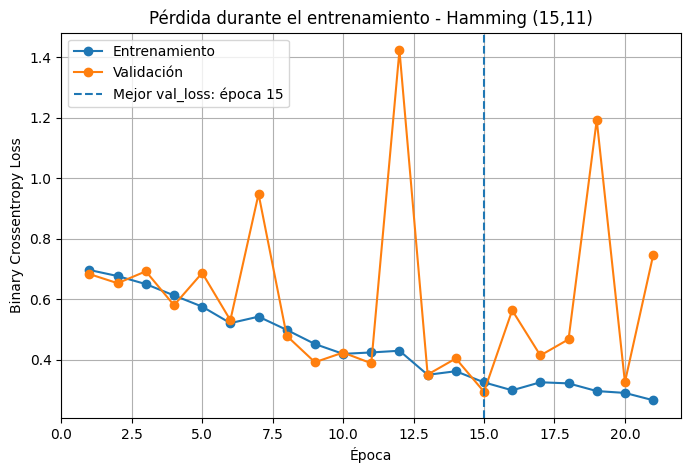

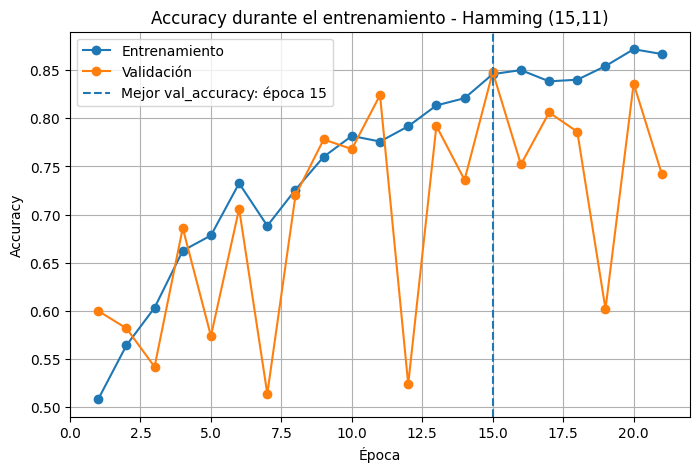

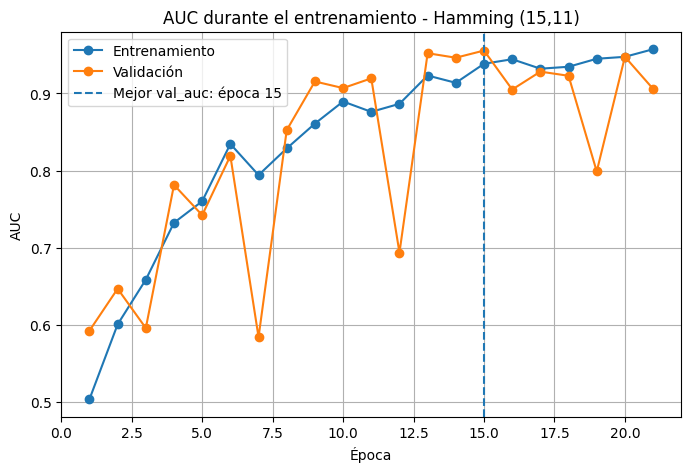

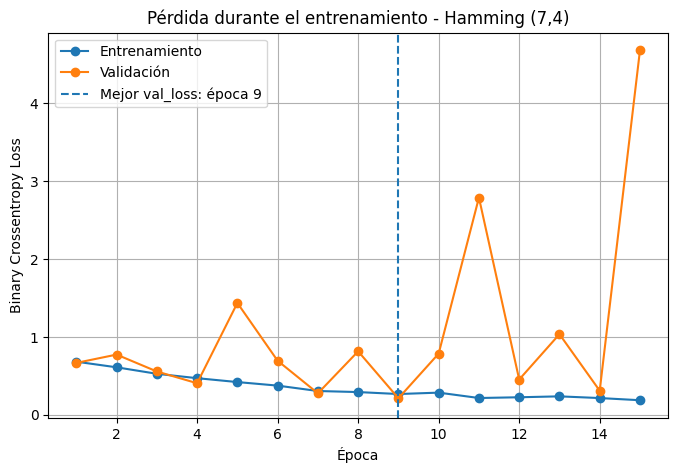

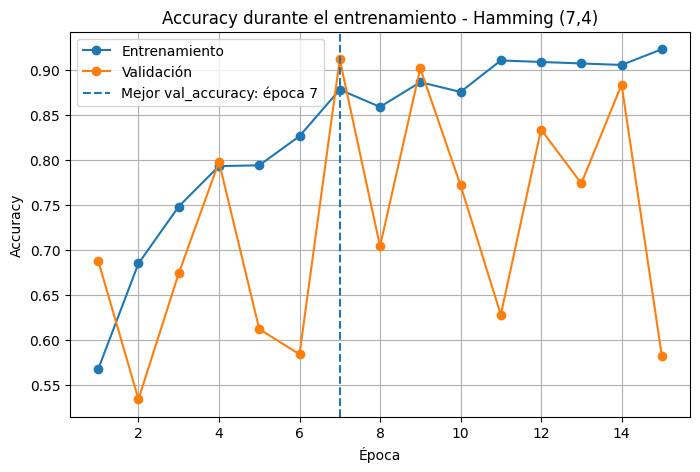

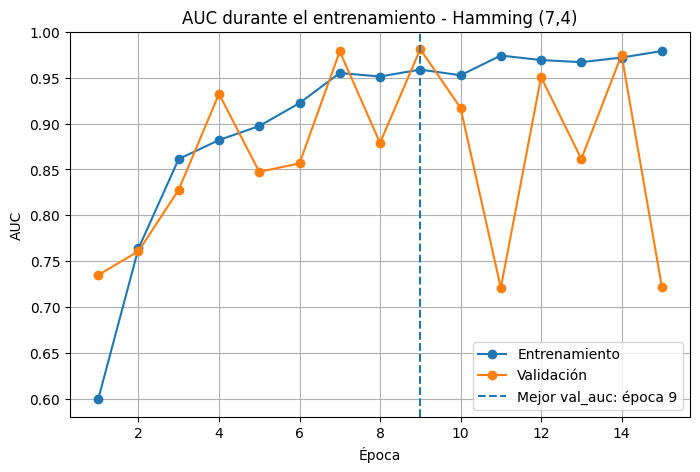

Checkpoint cargado para Hamming (15,11): mejor_modelo_stego_15.pt | época=15 | monitor=0.9555

DIAGNÓSTICO DE SOBREAJUSTE CON MEJOR CHECKPOINT: Hamming (15,11)
Mejor época histórica según val_loss: 15
Mejor val_loss histórico: 0.2943
Último val_loss histórico: 0.7450
Aumento relativo de val_loss respecto al mejor punto: 153.15%

Métricas reales evaluadas con el mismo estado de pesos:
Train loss: 0.2978 | Val loss: 0.2943
Train accuracy: 0.8375 | Val accuracy: 0.8480 | gap=-0.0105
Train AUC: 0.9532 | Val AUC: 0.9555 | gap=-0.0023

Interpretación:
No hay señales fuertes de sobreajuste.
El entrenamiento y la validación se comportan de forma relativamente similar.
Checkpoint cargado para Hamming (7,4): mejor_modelo_stego_7.pt | época=9 | monitor=0.9809

DIAGNÓSTICO DE SOBREAJUSTE CON MEJOR CHECKPOINT: Hamming (7,4)
Mejor época histórica según val_loss: 9
Mejor val_loss histórico: 0.2130
Último val_loss histórico: 4.6820
Aumento relativo de val_loss respecto al mejor punto: 2098.35%

Métric

In [66]:
# ============================================================
# DIAGNÓSTICO DE SOBREAJUSTE Y CURVAS DE ENTRENAMIENTO
# ============================================================

def graficar_curvas_entrenamiento(historial, nombre_modelo):
    hist = historial.history
    epocas = range(1, len(hist["loss"]) + 1)

    # ----------------------------
    # Gráfica de pérdida
    # ----------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epocas, hist["loss"], marker="o", label="Entrenamiento")
    plt.plot(epocas, hist["val_loss"], marker="o", label="Validación")

    mejor_epoca_loss = np.argmin(hist["val_loss"]) + 1

    plt.axvline(
        mejor_epoca_loss,
        linestyle="--",
        label=f"Mejor val_loss: época {mejor_epoca_loss}"
    )

    plt.title(f"Pérdida durante el entrenamiento - {nombre_modelo}")
    plt.xlabel("Época")
    plt.ylabel("Binary Crossentropy Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ----------------------------
    # Gráfica de accuracy
    # ----------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epocas, hist["accuracy"], marker="o", label="Entrenamiento")
    plt.plot(epocas, hist["val_accuracy"], marker="o", label="Validación")

    mejor_epoca_acc = np.argmax(hist["val_accuracy"]) + 1

    plt.axvline(
        mejor_epoca_acc,
        linestyle="--",
        label=f"Mejor val_accuracy: época {mejor_epoca_acc}"
    )

    plt.title(f"Accuracy durante el entrenamiento - {nombre_modelo}")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ----------------------------
    # Gráfica de AUC, si existe
    # ----------------------------
    if "auc" in hist and "val_auc" in hist:
        plt.figure(figsize=(8, 5))
        plt.plot(epocas, hist["auc"], marker="o", label="Entrenamiento")
        plt.plot(epocas, hist["val_auc"], marker="o", label="Validación")

        mejor_epoca_auc = np.nanargmax(hist["val_auc"]) + 1

        plt.axvline(
            mejor_epoca_auc,
            linestyle="--",
            label=f"Mejor val_auc: época {mejor_epoca_auc}"
        )

        plt.title(f"AUC durante el entrenamiento - {nombre_modelo}")
        plt.xlabel("Época")
        plt.ylabel("AUC")
        plt.legend()
        plt.grid(True)
        plt.show()


def cargar_mejor_checkpoint(modelo, ruta_checkpoint, nombre_modelo):
    if not os.path.exists(ruta_checkpoint):
        print(f"No se encontró checkpoint para {nombre_modelo}: {ruta_checkpoint}")
        return modelo

    # Necesario para checkpoints ya guardados con objetos NumPy dentro del historial.
    # Úsalo solo si el checkpoint fue generado por ti o por una fuente confiable.
    checkpoint = torch.load(
        ruta_checkpoint,
        map_location=device,
        weights_only=False
    )

    modelo.load_state_dict(checkpoint["model_state_dict"])
    modelo.to(device)
    modelo.eval()

    epoca = checkpoint.get("epoca", "desconocida")
    monitor = checkpoint.get("monitor", None)

    if monitor is not None:
        print(f"Checkpoint cargado para {nombre_modelo}: {ruta_checkpoint} | época={epoca} | monitor={monitor:.4f}")
    else:
        print(f"Checkpoint cargado para {nombre_modelo}: {ruta_checkpoint} | época={epoca}")

    return modelo


def evaluar_train_vs_val(modelo, train_ds, val_ds, nombre_modelo, imprimir=True):
    criterio = nn.BCEWithLogitsLoss()

    resultados_train = evaluar_modelo_pytorch(modelo, train_ds, criterio)
    resultados_val = evaluar_modelo_pytorch(modelo, val_ds, criterio)

    if imprimir:
        print("\n" + "="*70)
        print(f"EVALUACIÓN TRAIN VS VALIDATION: {nombre_modelo}")
        print("="*70)

        print("\nResultados en entrenamiento:")
        for metrica, valor in resultados_train.items():
            print(f"{metrica}: {valor:.4f}")

        print("\nResultados en validación:")
        for metrica, valor in resultados_val.items():
            print(f"{metrica}: {valor:.4f}")

        print("\nBrechas train - validation:")
        for metrica in resultados_train.keys():
            brecha = resultados_train[metrica] - resultados_val[metrica]
            print(f"{metrica}: {brecha:.4f}")

    return resultados_train, resultados_val


def diagnosticar_sobreajuste(modelo, train_loader, val_loader, historial, nombre_modelo):
    hist = historial.history
    train_loss_hist = np.array(hist["loss"])
    val_loss_hist = np.array(hist["val_loss"])

    mejor_epoca_val_loss = np.argmin(val_loss_hist)
    mejor_val_loss = val_loss_hist[mejor_epoca_val_loss]
    ultima_val_loss = val_loss_hist[-1]
    aumento_val_loss = (ultima_val_loss - mejor_val_loss) / max(abs(mejor_val_loss), 1e-8)

    resultados_train, resultados_val = evaluar_train_vs_val(
        modelo,
        train_loader,
        val_loader,
        nombre_modelo,
        imprimir=False
    )

    gap_acc = resultados_train["accuracy"] - resultados_val["accuracy"]
    gap_auc = resultados_train["auc"] - resultados_val["auc"]

    print("\n" + "="*70)
    print(f"DIAGNÓSTICO DE SOBREAJUSTE CON MEJOR CHECKPOINT: {nombre_modelo}")
    print("="*70)

    print(f"Mejor época histórica según val_loss: {mejor_epoca_val_loss + 1}")
    print(f"Mejor val_loss histórico: {mejor_val_loss:.4f}")
    print(f"Último val_loss histórico: {ultima_val_loss:.4f}")
    print(f"Aumento relativo de val_loss respecto al mejor punto: {aumento_val_loss*100:.2f}%")

    print("\nMétricas reales evaluadas con el mismo estado de pesos:")
    print(f"Train loss: {resultados_train['loss']:.4f} | Val loss: {resultados_val['loss']:.4f}")
    print(f"Train accuracy: {resultados_train['accuracy']:.4f} | Val accuracy: {resultados_val['accuracy']:.4f} | gap={gap_acc:.4f}")
    print(f"Train AUC: {resultados_train['auc']:.4f} | Val AUC: {resultados_val['auc']:.4f} | gap={gap_auc:.4f}")

    print("\nInterpretación:")

    if aumento_val_loss > 0.10 and (gap_acc > 0.08 or gap_auc > 0.08):
        print("Hay señales claras de SOBREAJUSTE.")
        print("El modelo mejora en entrenamiento, pero pierde generalización en validación.")

    elif gap_acc > 0.10 or gap_auc > 0.10:
        print("Hay posible SOBREAJUSTE.")
        print("La diferencia entre entrenamiento y validación es alta.")

    elif resultados_train['accuracy'] < 0.60 and resultados_val['accuracy'] < 0.60:
        print("No parece sobreajuste fuerte.")
        print("El problema parece más cercano a underfitting, colapso de clase o señal esteganográfica muy débil.")

    else:
        print("No hay señales fuertes de sobreajuste.")
        print("El entrenamiento y la validación se comportan de forma relativamente similar.")


# ============================================================
# EJECUTAR DIAGNÓSTICO PARA AMBOS MODELOS
# ============================================================

graficar_curvas_entrenamiento(
    historial,
    "Hamming (15,11)"
)

graficar_curvas_entrenamiento(
    historial_7,
    "Hamming (7,4)"
)


model_resnet = cargar_mejor_checkpoint(
    model_resnet,
    "mejor_modelo_stego_15.pt",
    "Hamming (15,11)"
)


diagnosticar_sobreajuste(
    model_resnet,
    train_dataset,
    val_dataset,
    historial,
    "Hamming (15,11)"
)

modelo_resnet_7 = cargar_mejor_checkpoint(
    modelo_resnet_7,
    "mejor_modelo_stego_7.pt",
    "Hamming (7,4)"
)


diagnosticar_sobreajuste(
    modelo_resnet_7,
    train_dataset_7,
    val_dataset_7,
    historial_7,
    "Hamming (7,4)"
)


In [67]:
# ============================================================
# EVALUACIÓN FINAL: TRAIN VS VALIDATION EN PYTORCH
# El test se mantiene separado y se evalúa una sola vez en la sección 4.2.
# ============================================================

evaluar_train_vs_val(
    model_resnet,
    train_dataset,
    val_dataset,
    "Hamming (15,11)"
)

evaluar_train_vs_val(
    modelo_resnet_7,
    train_dataset_7,
    val_dataset_7,
    "Hamming (7,4)"
)



EVALUACIÓN TRAIN VS VALIDATION: Hamming (15,11)

Resultados en entrenamiento:
loss: 0.2976
accuracy: 0.8350
auc: 0.9536

Resultados en validación:
loss: 0.2943
accuracy: 0.8480
auc: 0.9555

Brechas train - validation:
loss: 0.0033
accuracy: -0.0130
auc: -0.0019

EVALUACIÓN TRAIN VS VALIDATION: Hamming (7,4)

Resultados en entrenamiento:
loss: 0.1882
accuracy: 0.9150
auc: 0.9908

Resultados en validación:
loss: 0.2130
accuracy: 0.9020
auc: 0.9809

Brechas train - validation:
loss: -0.0248
accuracy: 0.0130
auc: 0.0098


({'loss': 0.18819313784440359,
  'accuracy': np.float64(0.915),
  'auc': 0.9907819444444443},
 {'loss': 0.21297961628437043, 'accuracy': np.float64(0.902), 'auc': 0.980944})

# **Fase 4: Evaluación y Discusión**

## **4.1. Evaluación de Fidelidad Visual (Métricas de Calidad)**

Para medir el impacto del *Matrix Embedding* en las imágenes de cobertura, se emplearon dos métricas estándar en el procesamiento de imágenes esteganográficas:

1. PSNR (Peak Signal-to-Noise Ratio): Mide la relación entre el máximo valor posible de un píxel y el ruido introducido por el ocultamiento (Error Cuadrático Medio o MSE). Se expresa en decibelios (dB). Un valor más alto indica una menor degradación visual. Su formulación matemática es:

$$MSE = \frac{1}{m\,n} \sum_{i=0}^{m-1} \sum_{j=0}^{n-1} [I(i,j) - K(i,j)]^2$$
$$PSNR = 10 \cdot \log_{10} \left( \frac{MAX_I^2}{MSE} \right)$$

2. SSIM (Structural Similarity Index Measure): A diferencia del PSNR, que mide el error absoluto, el SSIM evalúa la degradación de la estructura espacial de la imagen, modelando mejor la percepción del ojo humano. Sus valores oscilan entre $-1$ y $1$, donde $1$ indica una imagen idéntica a la original.

Se espera que el esquema basado en Hamming (15,11) reporte valores de PSNR y SSIM superiores a los de Hamming (7,4) bajo tasas de payload equivalentes, debido a su menor tasa de modificación de píxeles esperada.



In [68]:
# Rutas de los directorios usando el dataset ya existente
dir_cover = directorio_cover
dir_stego_7 = directorio_stego_7
dir_stego_15 = directorio_stego_15

def evaluar_dataset(ruta_cover, ruta_stego, limite=100):
    """
    Compara un conjunto de imágenes limpias vs estego y retorna el promedio de PSNR y SSIM.
    Se utiliza un límite para evaluar una muestra representativa y agilizar el cómputo.
    """
    imagenes_cover = sorted(glob.glob(os.path.join(ruta_cover, '*.png')))[:limite]

    lista_psnr = []
    lista_ssim = []

    for path_cov in imagenes_cover:
        nombre_archivo = os.path.basename(path_cov)
        path_stg = os.path.join(ruta_stego, nombre_archivo)

        if not os.path.exists(path_stg):
            continue

        # Cargar imágenes
        img_cov = cv2.imread(path_cov, cv2.IMREAD_GRAYSCALE)
        img_stg = cv2.imread(path_stg, cv2.IMREAD_GRAYSCALE)

        if img_cov is None or img_stg is None:
            continue

        # Calcular métricas
        val_psnr = compute_psnr(img_cov, img_stg, data_range=255)
        val_ssim = compute_ssim(img_cov, img_stg, data_range=255, win_size=11)

        lista_psnr.append(val_psnr)
        lista_ssim.append(val_ssim)

    return np.mean(lista_psnr), np.mean(lista_ssim)


In [69]:
# Evaluamos una muestra estocástica (ej. 100 imágenes) para obtener significancia estadística
MUESTRAS_EVALUACION = 100

psnr_7, ssim_7 = evaluar_dataset(dir_cover, dir_stego_7, limite=MUESTRAS_EVALUACION)
psnr_15, ssim_15 = evaluar_dataset(dir_cover, dir_stego_15, limite=MUESTRAS_EVALUACION)

print(f"\nResultados Promedio sobre {MUESTRAS_EVALUACION} imágenes:")
print("-" * 50)
print(f"Esquema Hamming (7,4):")
print(f" -> PSNR Promedio: {psnr_7:.2f} dB")
print(f" -> SSIM Promedio: {ssim_7:.4f}")
print("-" * 50)
print(f"Esquema Hamming (15,11):")
print(f" -> PSNR Promedio: {psnr_15:.2f} dB")
print(f" -> SSIM Promedio: {ssim_15:.4f}")
print("-" * 50)

# Verificación de hipótesis de tu documento
if psnr_15 > psnr_7:
    print("\n[ÉXITO] La hipótesis se confirma: Hamming (15,11) presenta menor distorsión visual (Mayor PSNR).")


Resultados Promedio sobre 100 imágenes:
--------------------------------------------------
Esquema Hamming (7,4):
 -> PSNR Promedio: 57.16 dB
 -> SSIM Promedio: 0.9992
--------------------------------------------------
Esquema Hamming (15,11):
 -> PSNR Promedio: 60.17 dB
 -> SSIM Promedio: 0.9996
--------------------------------------------------

[ÉXITO] La hipótesis se confirma: Hamming (15,11) presenta menor distorsión visual (Mayor PSNR).


## **4.2. Evaluación de la Red Residual (Métricas de Clasificación)**

La evaluación final de los modelos se realiza sobre el conjunto de test, el cual se mantuvo completamente separado durante el entrenamiento. Este conjunto no participa en el ajuste de pesos, selección de hiperparámetros, early stopping ni selección de checkpoints.

Para cada modelo se extraen las probabilidades predichas aplicando `sigmoid` sobre los logits producidos por la red. Luego, con un umbral estándar de `0.5`, se convierten esas probabilidades en etiquetas binarias:

```text
0 = cover
1 = stego
```


El desempeño se analiza mediante tres herramientas principales:

1. **Diagnóstico de distribución de predicciones:** permite observar si el modelo está produciendo probabilidades razonablemente distribuidas o si colapsa hacia una sola clase.
2. **Matriz de confusión:** permite identificar aciertos y errores por clase. En este proyecto, los falsos negativos son especialmente importantes, porque corresponden a imágenes stego clasificadas incorrectamente como imágenes limpias. Esta tasa se interpreta como una forma de evasión frente al estegoanalizador.
3. **Curva ROC y AUC:** permiten evaluar la capacidad del modelo para separar imágenes cover y stego sin depender exclusivamente de un único umbral de decisión. Un AUC cercano a `0.5` indica comportamiento similar al azar, mientras que un AUC cercano a `1.0` indica alta capacidad de detección.

Finalmente, se comparan los resultados de Hamming (7,4) y Hamming (15,11). Esta comparación permite discutir si la menor densidad de modificaciones del esquema (15,11) efectivamente dificulta la detección frente al modelo residual entrenado.


In [70]:
print("--- Extrayendo predicciones comparativas de los modelos PyTorch ---")

def obtener_predicciones(modelo, dataloader):
    """Extrae etiquetas reales y probabilidades de un DataLoader de PyTorch."""
    modelo.eval()
    y_real = []
    y_pred_prob = []

    with torch.no_grad():
        for img, label in dataloader:
            img = img.to(device, non_blocking=True)

            with autocast(device_type=AMP_DEVICE_TYPE, enabled=USAR_AMP):
                logits = modelo(img)

            preds = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            labels = label.detach().cpu().numpy().reshape(-1)

            y_real.extend(labels)
            y_pred_prob.extend(preds)

    return np.array(y_real), np.array(y_pred_prob).flatten()


--- Extrayendo predicciones comparativas de los modelos PyTorch ---


In [71]:
# ============================================================
# DIAGNÓSTICO DE COLAPSO DE CLASE
# ============================================================

def diagnosticar_predicciones(nombre, y_real, y_prob):
    y_real = y_real.reshape(-1).astype(int)
    y_prob = y_prob.reshape(-1)

    y_bin = (y_prob > 0.5).astype(int)

    print("\n" + "="*60)
    print(f"DIAGNÓSTICO: {nombre}")
    print("="*60)

    print(f"Clases reales:")
    print(f"  Cover  (0): {np.sum(y_real == 0)}")
    print(f"  Stego  (1): {np.sum(y_real == 1)}")

    print(f"\nPredicciones binarias con umbral 0.5:")
    print(f"  Predicho Cover (0): {np.sum(y_bin == 0)}")
    print(f"  Predicho Stego (1): {np.sum(y_bin == 1)}")

    print(f"\nProbabilidades:")
    print(f"  Media: {y_prob.mean():.4f}")
    print(f"  Mínima: {y_prob.min():.4f}")
    print(f"  Máxima: {y_prob.max():.4f}")
    print(f"  Desviación estándar: {y_prob.std():.4f}")

    if np.all(y_bin == 0):
        print("\nALERTA: el modelo está prediciendo TODO como cover.")
    elif np.all(y_bin == 1):
        print("\nALERTA: el modelo está prediciendo TODO como stego.")
    else:
        print("\nOK: el modelo está usando ambas clases.")

In [72]:
# Evaluación única sobre TEST. No usar estos resultados para ajustar el entrenamiento.
y_real_15, y_prob_15 = obtener_predicciones(model_resnet, test_dataset)
y_real_7, y_prob_7 = obtener_predicciones(modelo_resnet_7, test_dataset_7)

diagnosticar_predicciones("Hamming (15,11) - TEST", y_real_15, y_prob_15)
diagnosticar_predicciones("Hamming (7,4) - TEST", y_real_7, y_prob_7)



DIAGNÓSTICO: Hamming (15,11) - TEST
Clases reales:
  Cover  (0): 150
  Stego  (1): 150

Predicciones binarias con umbral 0.5:
  Predicho Cover (0): 183
  Predicho Stego (1): 117

Probabilidades:
  Media: 0.4456
  Mínima: 0.0001
  Máxima: 0.9990
  Desviación estándar: 0.3740

OK: el modelo está usando ambas clases.

DIAGNÓSTICO: Hamming (7,4) - TEST
Clases reales:
  Cover  (0): 150
  Stego  (1): 150

Predicciones binarias con umbral 0.5:
  Predicho Cover (0): 131
  Predicho Stego (1): 169

Probabilidades:
  Media: 0.5283
  Mínima: 0.0000
  Máxima: 1.0000
  Desviación estándar: 0.4116

OK: el modelo está usando ambas clases.


In [73]:
# 1. Usar las predicciones de TEST obtenidas en la celda anterior.
# No se vuelve a llamar obtener_predicciones para evitar evaluar el test más de una vez.
if "y_real_15" not in globals() or "y_prob_15" not in globals() or "y_real_7" not in globals() or "y_prob_7" not in globals():
    raise RuntimeError("Ejecuta primero la celda anterior para obtener las predicciones de test.")

# 2. Binarización mediante umbral estándar (0.5)
y_bin_15 = (y_prob_15 > 0.5).astype(int)
y_bin_7 = (y_prob_7 > 0.5).astype(int)

cm_15 = confusion_matrix(y_real_15, y_bin_15)
cm_7 = confusion_matrix(y_real_7, y_bin_7)

# 3. Cálculo de coordenadas para las Curvas ROC y AUC
fpr_15, tpr_15, _ = roc_curve(y_real_15, y_prob_15)
auc_15 = auc(fpr_15, tpr_15)

fpr_7, tpr_7, _ = roc_curve(y_real_7, y_prob_7)
auc_7 = auc(fpr_7, tpr_7)


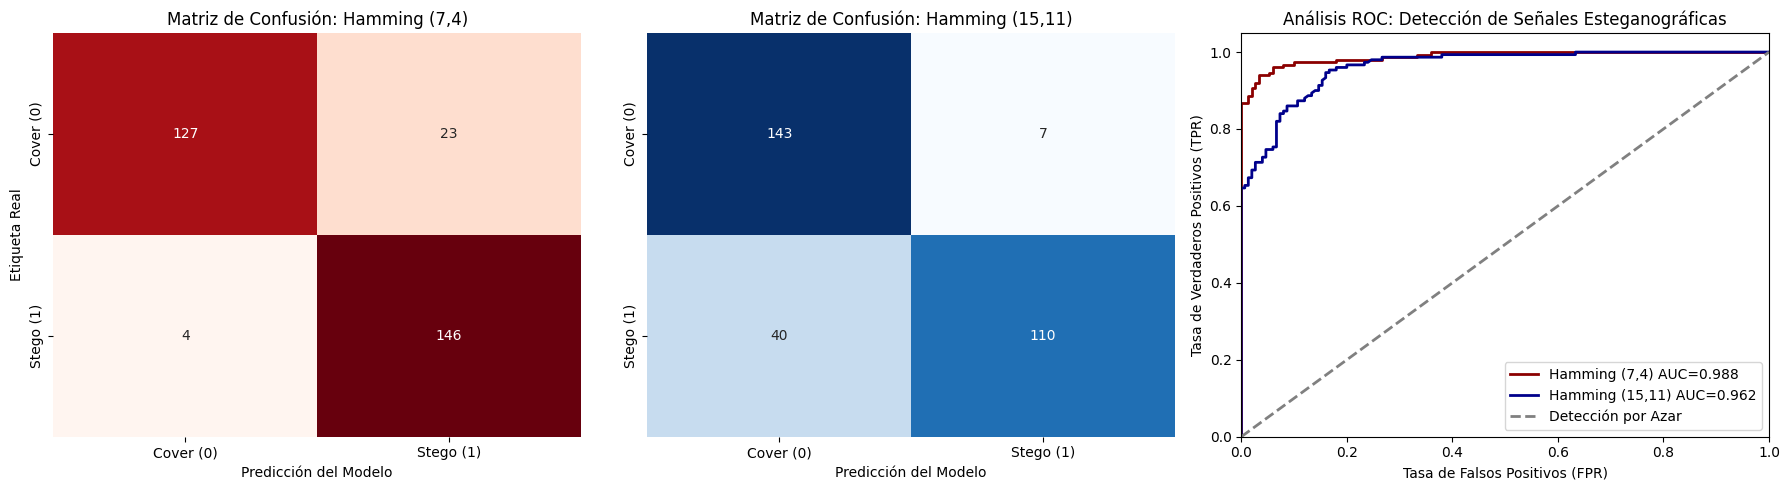

In [74]:
# --- 5. DIAGRAMACIÓN VISUAL UNIFICADA ---
plt.figure(figsize=(18, 5))

# Subplot 1: Matriz de Confusión 7,4 (Tonos Rojos para diferenciar)
plt.subplot(1, 3, 1)
sns.heatmap(cm_7, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Cover (0)', 'Stego (1)'],
            yticklabels=['Cover (0)', 'Stego (1)'])
plt.title('Matriz de Confusión: Hamming (7,4)')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')

# Subplot 2: Matriz de Confusión 15,11 (Tonos Azules)
plt.subplot(1, 3, 2)
sns.heatmap(cm_15, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Cover (0)', 'Stego (1)'],
            yticklabels=['Cover (0)', 'Stego (1)'])
plt.title('Matriz de Confusión: Hamming (15,11)')
plt.xlabel('Predicción del Modelo')

# Subplot 3: Curvas ROC Superpuestas
plt.subplot(1, 3, 3)
plt.plot(fpr_7, tpr_7, color='darkred', lw=2, label=f'Hamming (7,4) AUC={auc_7:.3f}')
plt.plot(fpr_15, tpr_15, color='darkblue', lw=2, label=f'Hamming (15,11) AUC={auc_15:.3f}')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Detección por Azar')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Análisis ROC: Detección de Señales Esteganográficas')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [75]:
# --- 6. Análisis Estadístico de Evasión ---
fn_7 = cm_7[1, 0]
total_7 = np.sum(cm_7[1, :])
tasa_evasion_7 = (fn_7 / total_7) * 100 if total_7 > 0 else 0

fn_15 = cm_15[1, 0]
total_15 = np.sum(cm_15[1, :])
tasa_evasion_15 = (fn_15 / total_15) * 100 if total_15 > 0 else 0

print("\n" + "="*50)
print("RESUMEN ESTADÍSTICO DE EVASIÓN ESTEGANOGRÁFICA")
print("="*50)
print(f"Esquema (7,4)   - Falsos Negativos: {fn_7}/{total_7} -> Tasa de Evasión: {tasa_evasion_7:.2f}%")
print(f"Esquema (15,11) - Falsos Negativos: {fn_15}/{total_15} -> Tasa de Evasión: {tasa_evasion_15:.2f}%")
print("-" * 50)

if tasa_evasion_15 > tasa_evasion_7:
    print("CONCLUSIÓN: Hipótesis confirmada. El esquema (15,11) es criptográficamente")
    print("más robusto y presenta mayor dificultad de detección forense.")
else:
    print("CONCLUSIÓN: El factor de regularización de la red mitigó el ruido en ambos")
    print("esquemas, logrando tasas de detección similares.")


RESUMEN ESTADÍSTICO DE EVASIÓN ESTEGANOGRÁFICA
Esquema (7,4)   - Falsos Negativos: 4/150 -> Tasa de Evasión: 2.67%
Esquema (15,11) - Falsos Negativos: 40/150 -> Tasa de Evasión: 26.67%
--------------------------------------------------
CONCLUSIÓN: Hipótesis confirmada. El esquema (15,11) es criptográficamente
más robusto y presenta mayor dificultad de detección forense.
